# PREDICTIVE ML MODEL TRAINING FOR PROCESS PUMP THROUGH SYNTHETICALLY GENERATED DATASET

### Set-up & Imports

In [47]:
# 0/ Setup & Imports
import warnings
warnings.filterwarnings('ignore')


import os
import json
import onnxmltools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from onnxmltools.convert.common.data_types import FloatTensorType
from sklearn.metrics import mean_absolute_error as MAE
from sklearn.metrics import mean_squared_error as MSE
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import r2_score
from IPython.display import display
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from scipy.stats import ks_2samp


# Reproducibility
np.random.seed(42)

# Display options for readable, aligned outputs
pd.set_option('display.width', 120)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 3)

# Small helpers for tidy logs
def print_header(title: str):
    line = '=' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_footer(title: str):
    line = '-' * 70
    print(f"\n{line}\n{title}\n{line}")

def print_kv(pairs):
    # pairs: list of (key, value)
    width = max(len(str(k)) for k, _ in pairs) if pairs else 0
    for k, v in pairs:
        print(f"{str(k).ljust(width)} : {v}")

def R_MSE(y_true, y_pred):
    return np.sqrt(MSE(y_true, y_pred))

def get_numeric_sensor_cols(df: pd.DataFrame, exclude_cols: set) -> list:
    cols = []
    for c in df.columns:
        if c in exclude_cols:
            continue
        if pd.api.types.is_numeric_dtype(df[c]):
            cols.append(c)
    return cols

# Create models directory if it doesn't exist
if not os.path.exists("models_and_features"):
    os.makedirs("models_and_features")
    if not os.path.exists("models_and_features/process_pump"):
        os.makedirs("models_and_features/process_pump")
    if not os.path.exists("models_and_features") or not os.path.exists("models_and_features/process_pump"):
        raise RuntimeError("Failed to create models_and_features directory")

save_path= "models_and_features/process_pump/"

print_footer("SETUP AND IMPORTS COMPLETE")



----------------------------------------------------------------------
SETUP AND IMPORTS COMPLETE
----------------------------------------------------------------------


## 1) Dataset Load & Basic Inspection

In [48]:
# 1/ Dataset Load & Basic Inspection

print("1/ DATASET LOAD")

def summarize_df(name, df):
    rows, cols = df.shape
    dtypes = df.dtypes.value_counts()
    dtype_str = ", ".join([f"{dt}: {cnt}" for dt, cnt in dtypes.items()])
    pairs = [
                (f"{name} rows", rows),
                (f"{name} cols", cols),
                (f"{name} dtypes", dtype_str),
            ]
    print("\n".join(f"{k}: {v}" for k, v in pairs))

df_long_life = pd.read_csv("synthetic_pump_data_long_life.csv")
df_short_life = pd.read_csv("synthetic_pump_data_short_life.csv")

print("Long-life dataset:")
print(df_long_life.shape)
print("RUL range:", df_long_life["current_rul"].min(), "-", df_long_life["current_rul"].max())

print("\nShort-life dataset:")
print(df_short_life.shape)
print("RUL range:", df_short_life["current_rul"].min(), "-", df_short_life["current_rul"].max())

print_footer("DATASET LOAD COMPLETE")



1/ DATASET LOAD
Long-life dataset:
(2325453, 8)
RUL range: 0 - 47397

Short-life dataset:
(53756, 8)
RUL range: 0 - 599

----------------------------------------------------------------------
DATASET LOAD COMPLETE
----------------------------------------------------------------------


In [49]:
# 1A/ long-life dataset summary

print_header("1A/ LONG-LIFE DATASET SUMMARY")

df_raw_long_life = df_long_life.copy()

# Basic info
summarize_df("Merged DataFrame", df_raw_long_life)

print("-" * 40)
print("\nColumns:")
print(df_raw_long_life.columns.tolist())
print("-" * 40)

print("\nDescription:")
print(df_raw_long_life.describe().T)
print("-" * 40)

print("\nNull Values:")
null_values = df_raw_long_life.isnull().sum().sum()
print(f"NULL Total: {null_values}")
print("-" * 40)

print("\nDuplicate Rows:")
duplicate_rows = df_raw_long_life.duplicated().sum()
print(f"Duplicate Total: {duplicate_rows}")
print("-" * 40)

print("\nUnique Values")
unique_values = df_raw_long_life.nunique().sum()
print(f"Unique Total: {unique_values}")
print("-" * 40)

# Create a timestamp column from time_min
start_date = pd.Timestamp("2026-01-01")  # Define the start date for each cycle
df_raw_long_life['timestamp'] = df_raw_long_life.apply(lambda row: start_date + pd.Timedelta(minutes=row['time_min']), axis=1)

# Convert timestamp to datetime and check for differences
timestamp_diffs = df_raw_long_life['timestamp'].diff().dropna()
timestamp_diffs_seconds = timestamp_diffs.dt.total_seconds()                        # type: ignore

print("\nFirst 10 timestamp differences (seconds):")
print(timestamp_diffs.head(10).dt.total_seconds())                                  # type: ignore
print(f"Average increase (seconds): {timestamp_diffs_seconds.mean():.1f}")
print(f"Average increase (minutes): {timestamp_diffs_seconds.mean()/60:.2f}")
print("-" * 40)

# RUL Min - Max time
rul_min = df_raw_long_life['current_rul'].min()
rul_max = df_raw_long_life['current_rul'].max()

print(f"\nRUL Min - Max time (minutes): {rul_min} - {rul_max:.2f} minutes")
print(f"RUL Min - Max time (hours): {rul_min/60} - {rul_max/60:.2f} hours")

print("\nRow count per cycle:")
print(df_raw_long_life['cycle_id'].value_counts().sort_index())

# RUL distribution
print("\nTotal RUL distribution:")
print(df_raw_long_life['total_rul'].value_counts())

print_footer("LONG-LIFE DATASET SUMMARY COMPLETE")


1A/ LONG-LIFE DATASET SUMMARY
Merged DataFrame rows: 2325453
Merged DataFrame cols: 8
Merged DataFrame dtypes: int64: 4, float64: 4
----------------------------------------

Columns:
['cycle_id', 'time_min', 'total_rul', 'current_rul', 'vibration', 'temp_motor', 'pressure', 'vib_motor']
----------------------------------------

Description:
                 count       mean        std        min        25%        50%        75%        max
cycle_id     2.325e+06     30.765     17.244      1.000     16.000     31.000     46.000     60.000
time_min     2.325e+06  19741.453  11796.670      0.000   9689.000  19378.000  29068.000  47397.000
total_rul    2.325e+06  39483.905   5266.823  30444.000  34100.000  39707.000  44622.000  47398.000
current_rul  2.325e+06  19741.453  11796.670      0.000   9689.000  19378.000  29068.000  47397.000
vibration    2.325e+06      1.452      1.272     -0.356      0.403      1.062      2.184      8.925
temp_motor   2.325e+06    305.014    181.665     39.702 

In [50]:
# 1B/ Short-life dataset summary

print_header("1B/ SHORT-LIFE DATASET SUMMARY")

df_raw_short_life = df_short_life.copy()

# Basic info
summarize_df("Merged DataFrame", df_raw_short_life)

print("-" * 40)
print("\nColumns:")
print(df_raw_short_life.columns.tolist())
print("-" * 40)

print("\nDescription:")
print(df_raw_short_life.describe().T)
print("-" * 40)

print("\nNull Values:")
null_values = df_raw_short_life.isnull().sum().sum()
print(f"NULL Total: {null_values}")
print("-" * 40)

print("\nDuplicate Rows:")
duplicate_rows = df_raw_short_life.duplicated().sum()
print(f"Duplicate Total: {duplicate_rows}")
print("-" * 40)

print("\nUnique Values")
unique_values = df_raw_short_life.nunique().sum()
print(f"Unique Total: {unique_values}")
print("-" * 40)

# Create a timestamp column from time_min
start_date = pd.Timestamp("2026-01-01")  # Define the start date for each cycle
df_raw_short_life['timestamp'] = df_raw_short_life.apply(lambda row: start_date + pd.Timedelta(minutes=row['time_min']), axis=1)

# Convert timestamp to datetime and check for differences
timestamp_diffs = df_raw_short_life['timestamp'].diff().dropna()
timestamp_diffs_seconds = timestamp_diffs.dt.total_seconds()                        # type: ignore

print("\nFirst 10 timestamp differences (seconds):")
print(timestamp_diffs.head(10).dt.total_seconds())                                  # type: ignore
print(f"Average increase (seconds): {timestamp_diffs_seconds.mean():.1f}")
print(f"Average increase (minutes): {timestamp_diffs_seconds.mean()/60:.2f}")
print("-" * 40)

# RUL Min - Max time
rul_min = df_raw_short_life['current_rul'].min()
rul_max = df_raw_short_life['current_rul'].max()

print(f"\nRUL Min - Max time (minutes): {rul_min} - {rul_max:.2f} minutes")
print(f"RUL Min - Max time (hours): {rul_min/60} - {rul_max/60:.2f} hours")

print("\nRow count per cycle:")
print(df_raw_short_life['cycle_id'].value_counts().sort_index())

# RUL distribution
print("\nTotal RUL distribution:")
print(df_raw_short_life['total_rul'].value_counts())

print_footer("SHORT-LIFE DATASET SUMMARY COMPLETE")


1B/ SHORT-LIFE DATASET SUMMARY
Merged DataFrame rows: 53756
Merged DataFrame cols: 8
Merged DataFrame dtypes: int64: 4, float64: 4
----------------------------------------

Columns:
['cycle_id', 'time_min', 'total_rul', 'current_rul', 'vibration', 'temp_motor', 'pressure', 'vib_motor']
----------------------------------------

Description:
               count     mean      std      min      25%      50%      75%      max
cycle_id     53756.0   60.432   34.927    1.000   30.000   60.000   91.000  120.000
time_min     53756.0  230.601  141.104    0.000  111.000  223.000  337.000  599.000
total_rul    53756.0  462.202   79.514  317.000  392.000  457.000  530.000  600.000
current_rul  53756.0  230.601  141.104    0.000  111.000  223.000  337.000  599.000
vibration    53756.0    1.595    1.611   -0.214    0.384    1.034    2.270    8.969
temp_motor   53756.0   53.257    6.733   40.008   47.494   53.093   58.885   73.288
pressure     53756.0    7.504    0.467    5.137    7.256    7.567    

## 2) Explanatory Data Analysis (EDA)

2/ EXPLORATORY DATA ANALYSIS - Compact sensor overview (overlayed cycles)
Selected cycles to plot ((Short Life)): [5, 45, 48, 56]


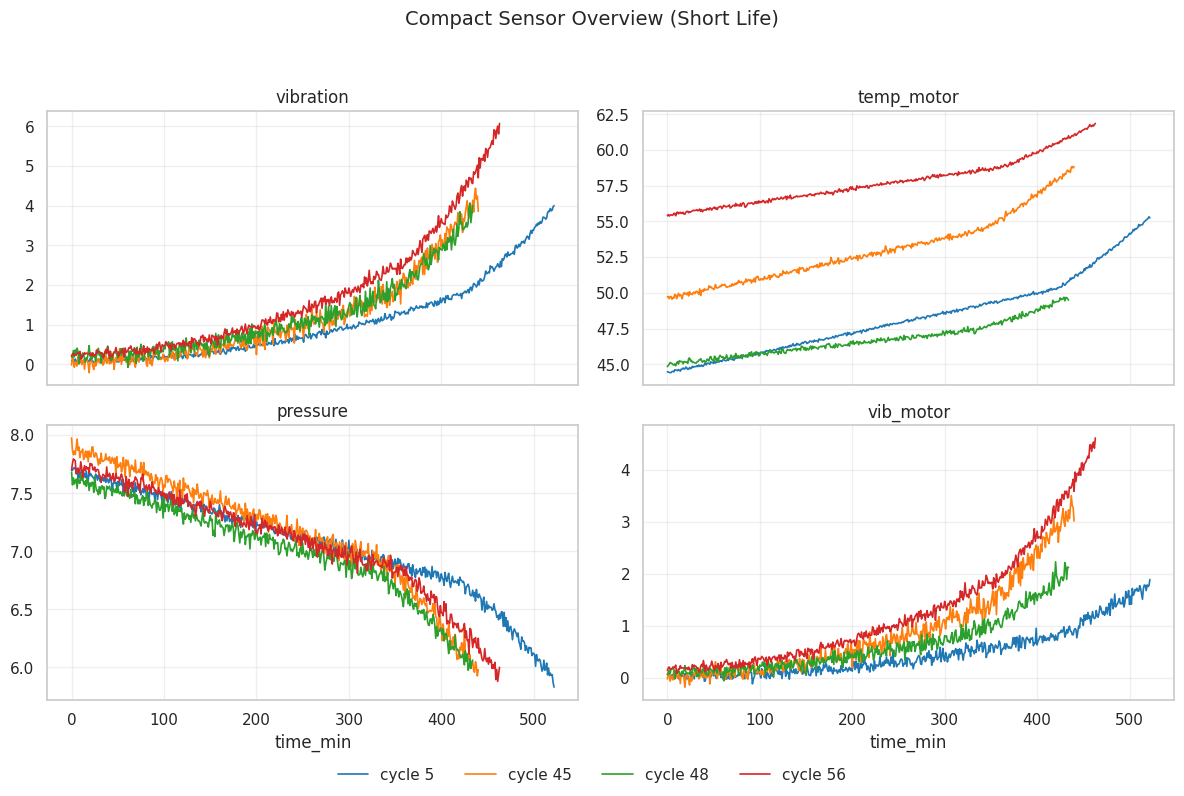

Selected cycles to plot ((Long Life)): [1, 6, 37, 46]


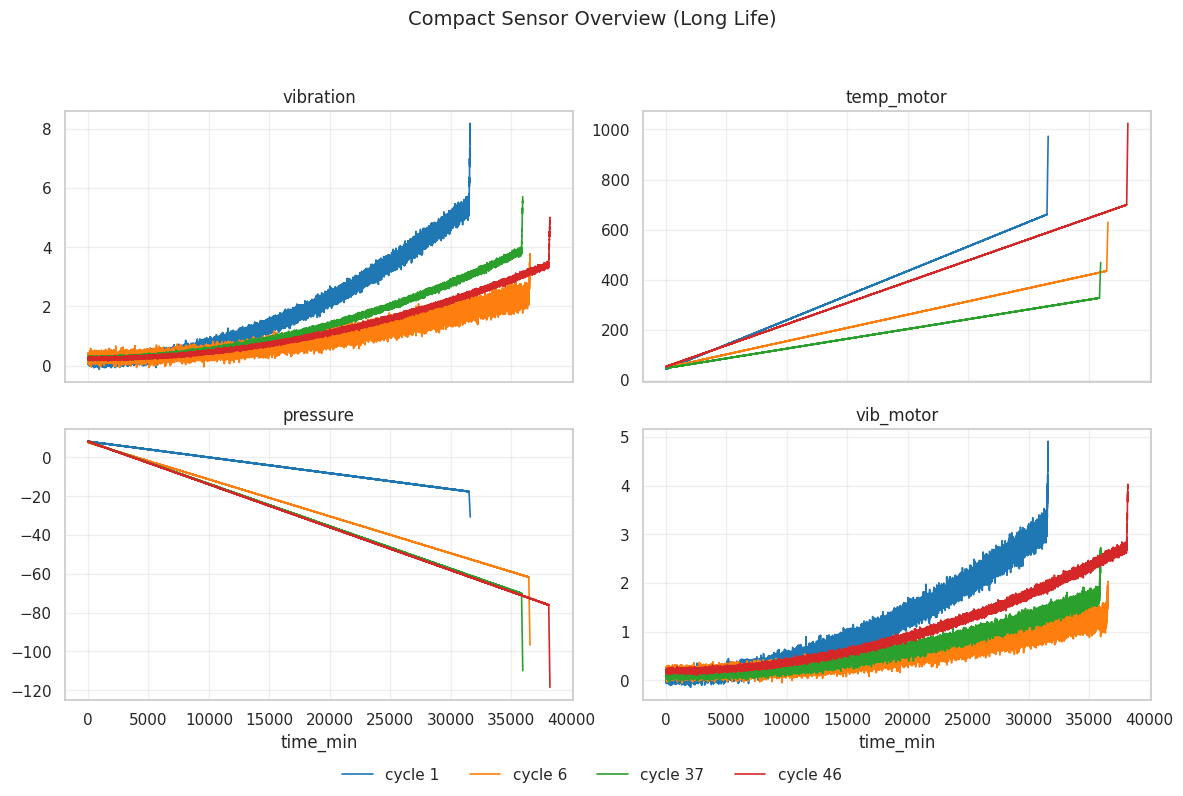

In [51]:
print("2/ EXPLORATORY DATA ANALYSIS - Compact sensor overview (overlayed cycles)")

# Ensure datasets are loaded
assert 'df_raw_short_life' in globals() and 'df_raw_long_life' in globals(), "Datasets must be defined (run dataset load cells)"


def plot_compact_cycles(df_raw, title_suffix=""):
    # Sensors to plot (one subplot per sensor)
    sensor_cols = ['vibration', 'temp_motor', 'pressure', 'vib_motor']
    # Verify sensors present
    missing = [c for c in sensor_cols if c not in df_raw.columns]
    if missing:
        print(f"Warning: missing columns: {missing}")
        sensor_cols = [c for c in sensor_cols if c in df_raw.columns]

    # Select a few cycles to compare (reproducible random selection)
    np.random.seed(42)
    unique_cycles = sorted(df_raw['cycle_id'].unique())
    n_plots = min(4, len(unique_cycles))
    assert n_plots > 0, "No cycles available to plot"
    selected_cycles = sorted(np.random.choice(unique_cycles, size=n_plots, replace=False))
    print(f"Selected cycles to plot ({title_suffix}): {selected_cycles}")

    # Set plotting style
    try:
        sns.set_theme(style='whitegrid')
    except Exception:
        try:
            sns.set_style('whitegrid')
        except Exception:
            if 'whitegrid' in plt.style.available:
                plt.style.use('whitegrid')
            else:
                plt.style.use('default')

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    axes = axes.flatten()
    # Color palette with fallback
    try:
        colors = sns.color_palette('tab10', n_plots)
    except Exception:
        colors = list(plt.cm.get_cmap('tab10').colors)[:n_plots]  # type: ignore

    for i, s in enumerate(sensor_cols):
        ax = axes[i]
        for j, c in enumerate(selected_cycles):
            sub = df_raw[df_raw['cycle_id'] == c].sort_values('time_min')
            ax.plot(sub['time_min'], sub[s], label=f'cycle {c}', color=colors[j], linewidth=1.2)  # type: ignore
        ax.set_title(s)
        ax.grid(alpha=0.3)

    # Common x label on bottom
    for ax in axes[-2:]:
        ax.set_xlabel('time_min')

    # Place legend below the plots in a compact form
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=n_plots, frameon=False)
    fig.suptitle(f"Compact Sensor Overview {title_suffix}", fontsize=14)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    plt.show()


# Run for both datasets
plot_compact_cycles(df_raw_short_life, title_suffix="(Short Life)")
plot_compact_cycles(df_raw_long_life, title_suffix="(Long Life)")

### 2A) Additional EDA: RUL, Correlation & Distributions

2A/ ADDITIONAL EDA - RUL time-series, sensor correlations, and boxplots
----------------------------------------
Short-Life Dataset:
----------------------------------------
Sensors used (Short Life): ['vibration', 'temp_motor', 'pressure', 'vib_motor']
Selected cycles for RUL time-series (Short Life): [5, 45, 48, 56]


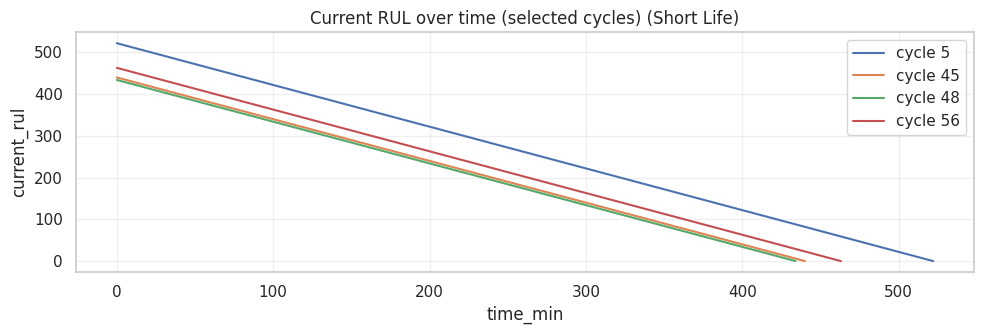

Sensor correlations with current_rul (Short Life) (sorted by absolute value):
vibration     0.798
vib_motor     0.761
pressure      0.595
temp_motor    0.256
Name: abs_corr, dtype: float64


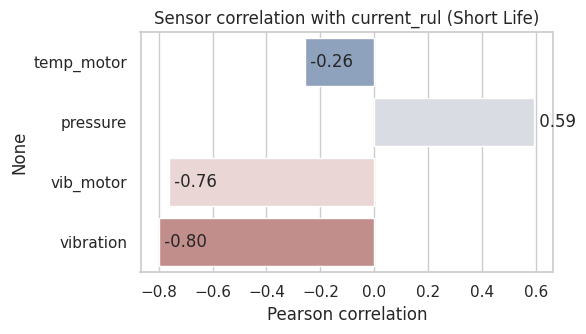

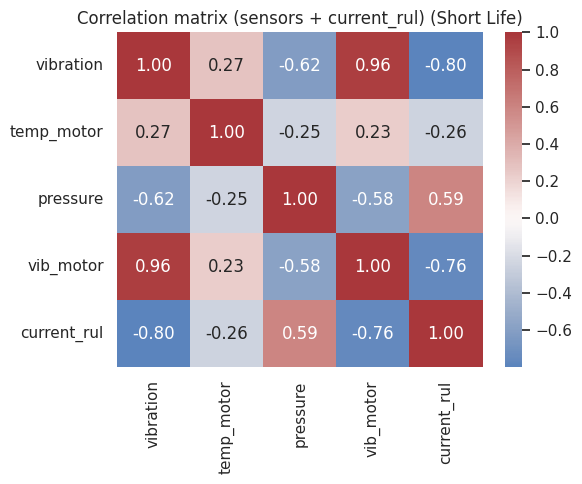

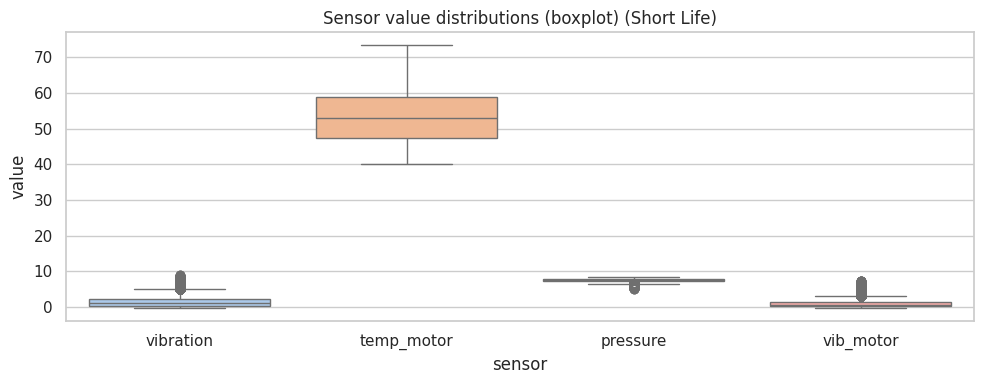

----------------------------------------
Long-Life Dataset:
----------------------------------------
Sensors used (Long Life): ['vibration', 'temp_motor', 'pressure', 'vib_motor']
Selected cycles for RUL time-series (Long Life): [1, 6, 37, 46]


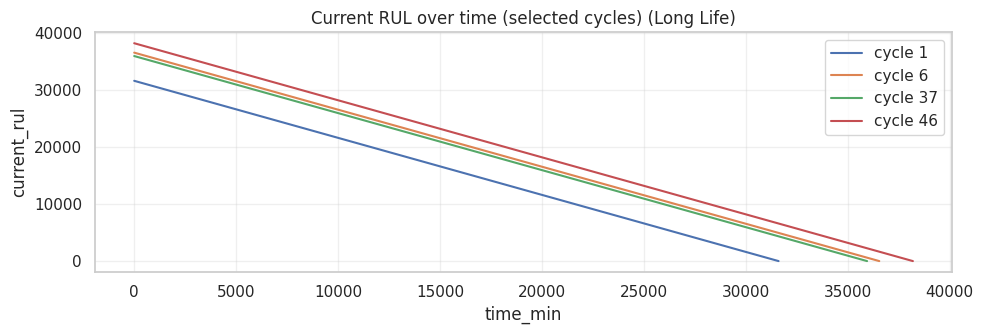

Sensor correlations with current_rul (Long Life) (sorted by absolute value):
vibration     0.844
vib_motor     0.801
temp_motor    0.765
pressure      0.684
Name: abs_corr, dtype: float64


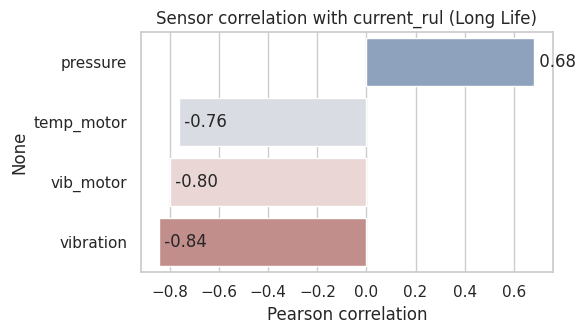

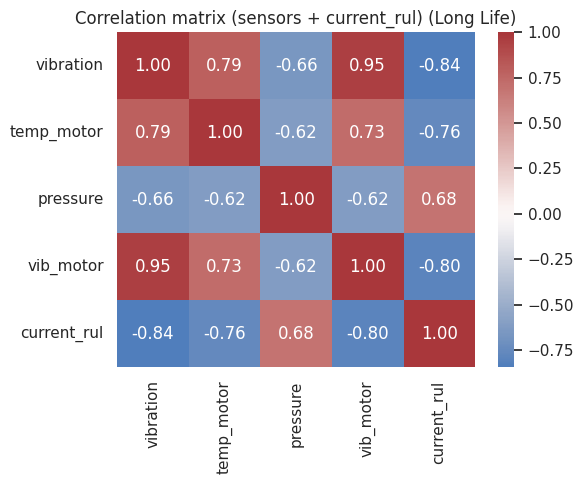

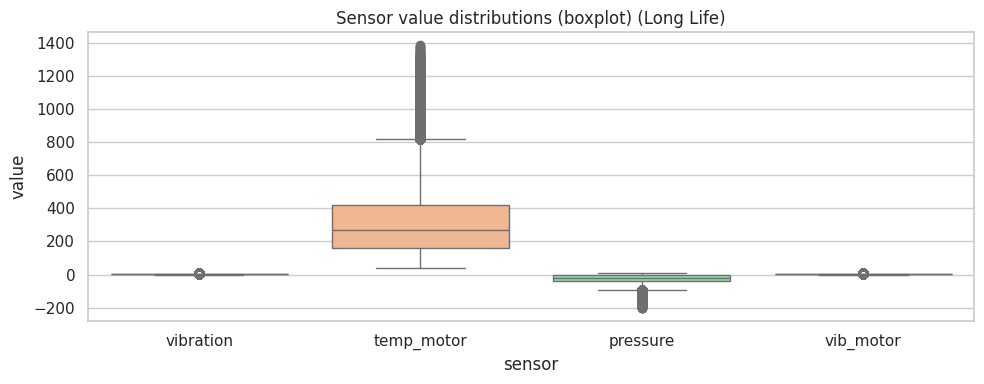

In [52]:
# 2A/ Additional EDA
print("2A/ ADDITIONAL EDA - RUL time-series, sensor correlations, and boxplots")

# Ensure datasets are loaded
assert 'df_raw_short_life' in globals() and 'df_raw_long_life' in globals(), "Datasets must be defined (run dataset load cells)"


def additional_eda(df_raw, title_suffix=""):
    # Sensors to inspect
    sensors = ['vibration', 'temp_motor', 'pressure', 'vib_motor']
    available_sensors = [s for s in sensors if s in df_raw.columns]
    if not available_sensors:
        print(f"No sensor columns available for 2A EDA {title_suffix}")
        return
    else:
        print(f"Sensors used {title_suffix}: {available_sensors}")

    # Select a few cycles to plot (same logic as before)
    np.random.seed(42)
    unique_cycles = sorted(df_raw['cycle_id'].unique())
    num_cycles = min(4, len(unique_cycles))
    selected_cycles = sorted(np.random.choice(unique_cycles, size=num_cycles, replace=False))
    print(f"Selected cycles for RUL time-series {title_suffix}: {selected_cycles}")

    # Plot RUL time-series
    plt.figure(figsize=(10, 3.5))
    for c in selected_cycles:
        sub = df_raw[df_raw['cycle_id'] == c].sort_values('time_min')
        plt.plot(sub['time_min'], sub['current_rul'], label=f'cycle {c}', linewidth=1.5)
    plt.xlabel('time_min')
    plt.ylabel('current_rul')
    plt.title(f'Current RUL over time (selected cycles) {title_suffix}')
    plt.grid(alpha=0.3)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # Correlation between sensors and current_rul
    if 'current_rul' not in df_raw.columns:
        print(f"Warning: 'current_rul' column not found in {title_suffix}; skipping correlation analysis")
        return
    else:
        corr_df = df_raw[available_sensors + ['current_rul']].corr()
        rul_corr = corr_df['current_rul'].drop('current_rul')
        print(f"Sensor correlations with current_rul {title_suffix} (sorted by absolute value):")
        print(rul_corr.abs().sort_values(ascending=False).rename('abs_corr'))

    # Barplot of correlations
    plt.figure(figsize=(6, 3.5))
    rul_corr_sorted = rul_corr.loc[rul_corr.abs().sort_values(ascending=True).index]
    sns.barplot(x=rul_corr_sorted.values, y=rul_corr_sorted.index, palette='vlag')
    plt.xlabel('Pearson correlation')
    plt.title(f'Sensor correlation with current_rul {title_suffix}')
    for i, v in enumerate(rul_corr_sorted.values):
        plt.text(v, i, f" {v:.2f}", va='center')
    plt.tight_layout()
    plt.show()

    # Heatmap of sensor + RUL correlations
    plt.figure(figsize=(6, 5))
    sns.heatmap(corr_df.loc[available_sensors + ['current_rul'], available_sensors + ['current_rul']],
                annot=True, fmt='.2f', cmap='vlag', center=0)
    plt.title(f'Correlation matrix (sensors + current_rul) {title_suffix}')
    plt.tight_layout()
    plt.show()

    # Boxplots of sensor distributions
    if available_sensors:
        melt = df_raw[available_sensors].melt(var_name='sensor', value_name='value')
        plt.figure(figsize=(10, 4))
        sns.boxplot(x='sensor', y='value', data=melt, palette='pastel')
        plt.title(f'Sensor value distributions (boxplot) {title_suffix}')
        plt.xlabel('sensor')
        plt.tight_layout()
        plt.show()


# Run for both datasets
print('-' * 40)
print("Short-Life Dataset:")
print('-' * 40)
additional_eda(df_raw_short_life, title_suffix="(Short Life)")

print('-' * 40)
print("Long-Life Dataset:")
print('-' * 40)
additional_eda(df_raw_long_life, title_suffix="(Long Life)")

### 2B) Cycle-to-cycle comparison (start vs end)

2B/ CYCLE COMPARISONS - start vs end summaries and plots
Comparing sensors (Short Life): ['vibration', 'temp_motor', 'pressure', 'vib_motor']

Example start/end table (Short Life) (first 8 cycles):


,cycle_id,vibration_start,temp_motor_start,pressure_start,vib_motor_start,vibration_end,temp_motor_end,pressure_end,vib_motor_end
0,1,0.197,44.538,7.833,0.089,4.262,53.659,7.170,2.052
1,2,0.301,51.070,7.601,0.149,3.122,60.013,6.234,1.664
2,3,0.085,42.688,8.270,0.060,3.566,52.120,7.517,1.533
3,4,0.038,48.032,8.370,0.060,6.279,59.532,7.041,5.119
4,5,0.097,44.476,7.694,0.069,3.999,55.240,5.830,1.893
5,6,0.285,50.433,7.887,0.144,6.760,56.163,7.015,3.339
6,7,0.047,57.934,7.939,0.009,5.485,72.231,6.962,3.564
7,8,0.083,54.818,8.083,0.182,6.102,62.405,6.487,4.681



Delta summary (Short Life) (end - start):
                  count   mean    std    min    25%    50%     75%     max
vibration_delta   120.0  5.648  1.728  2.785  4.020  5.599   7.274   8.859
temp_motor_delta  120.0  8.447  3.213  2.748  5.840  8.557  10.580  16.670
pressure_delta    120.0 -1.256  0.547 -2.644 -1.618 -1.274  -0.824  -0.207
vib_motor_delta   120.0  3.581  1.398  1.412  2.425  3.244   4.704   7.210


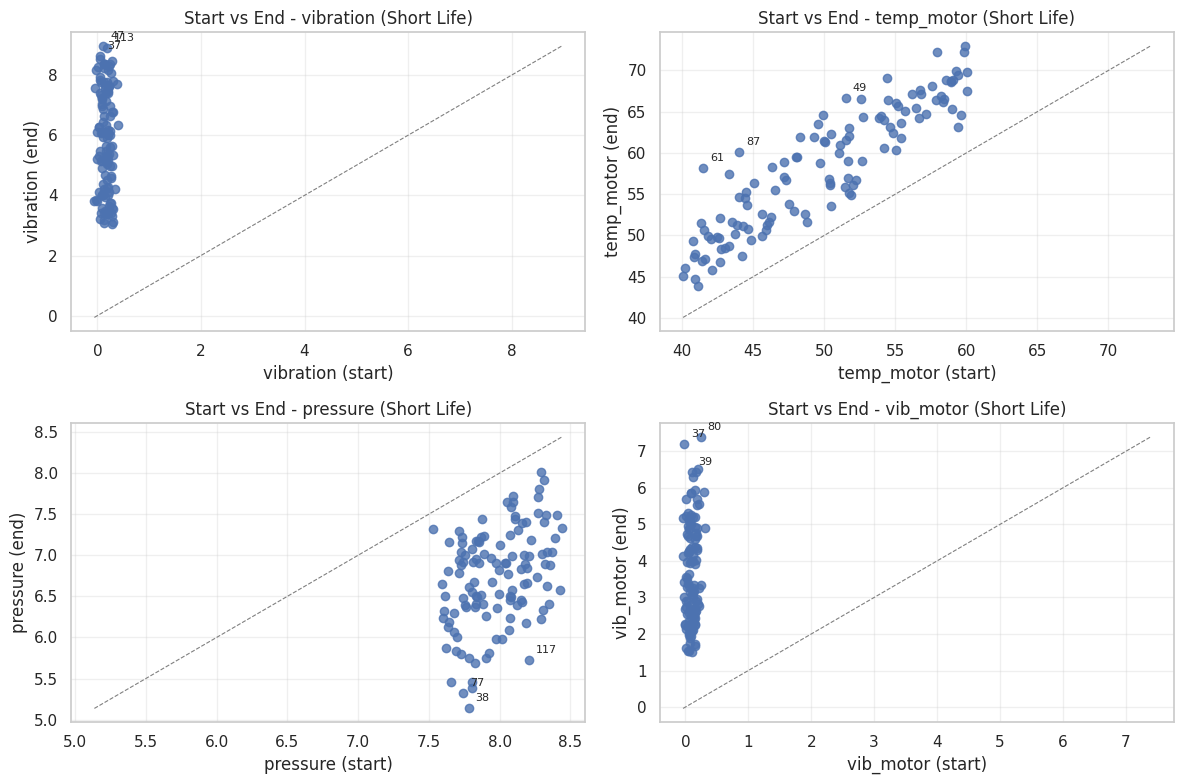


Top 3 cycles with largest increase in vibration (Short Life) (end - start):
     cycle_id  vibration_start  vibration_end  vibration_delta
46         47            0.110          8.969            8.859
112       113            0.178          8.891            8.713
36         37            0.049          8.622            8.573
Top 3 cycles with largest decrease in vibration (Short Life):
    cycle_id  vibration_start  vibration_end  vibration_delta
17        18            0.277          3.062            2.785
1          2            0.301          3.122            2.822
41        42            0.135          3.077            2.942

Top 3 cycles with largest increase in temp_motor (Short Life) (end - start):
    cycle_id  temp_motor_start  temp_motor_end  temp_motor_delta
60        61            41.473          58.143            16.670
86        87            43.999          60.071            16.072
48        49            51.512          66.699            15.187
Top 3 cycles with large

,cycle_id,vibration_start,temp_motor_start,pressure_start,vib_motor_start,vibration_end,temp_motor_end,pressure_end,vib_motor_end
0,1,0.148,42.421,8.158,0.117,7.933,972.825,-30.724,4.665
1,2,0.208,56.186,7.910,0.133,6.741,1299.598,-101.680,4.600
2,3,0.106,45.688,8.324,0.072,7.905,440.274,-19.150,5.476
3,4,0.197,42.981,7.628,0.090,8.246,1382.202,-111.922,4.615
4,5,0.255,49.382,8.094,0.218,3.243,378.981,-98.190,2.479
5,6,0.341,48.388,7.732,0.170,3.777,629.411,-96.752,2.030
6,7,0.273,58.884,8.028,0.213,8.783,1318.582,-183.137,6.920
7,8,0.293,54.670,8.025,0.187,4.253,1188.757,-44.730,2.861



Delta summary (Long Life) (end - start):
                  count     mean      std      min      25%      50%      75%       max
vibration_delta    60.0    5.726    1.778    2.880    4.092    5.438    7.129     8.777
temp_motor_delta   60.0  754.318  264.923  283.691  580.292  735.843  935.294  1339.221
pressure_delta     60.0  -99.274   45.305 -209.124 -121.343  -90.519  -60.643   -27.474
vib_motor_delta    60.0    3.775    1.458    1.344    2.667    3.541    4.507     7.347


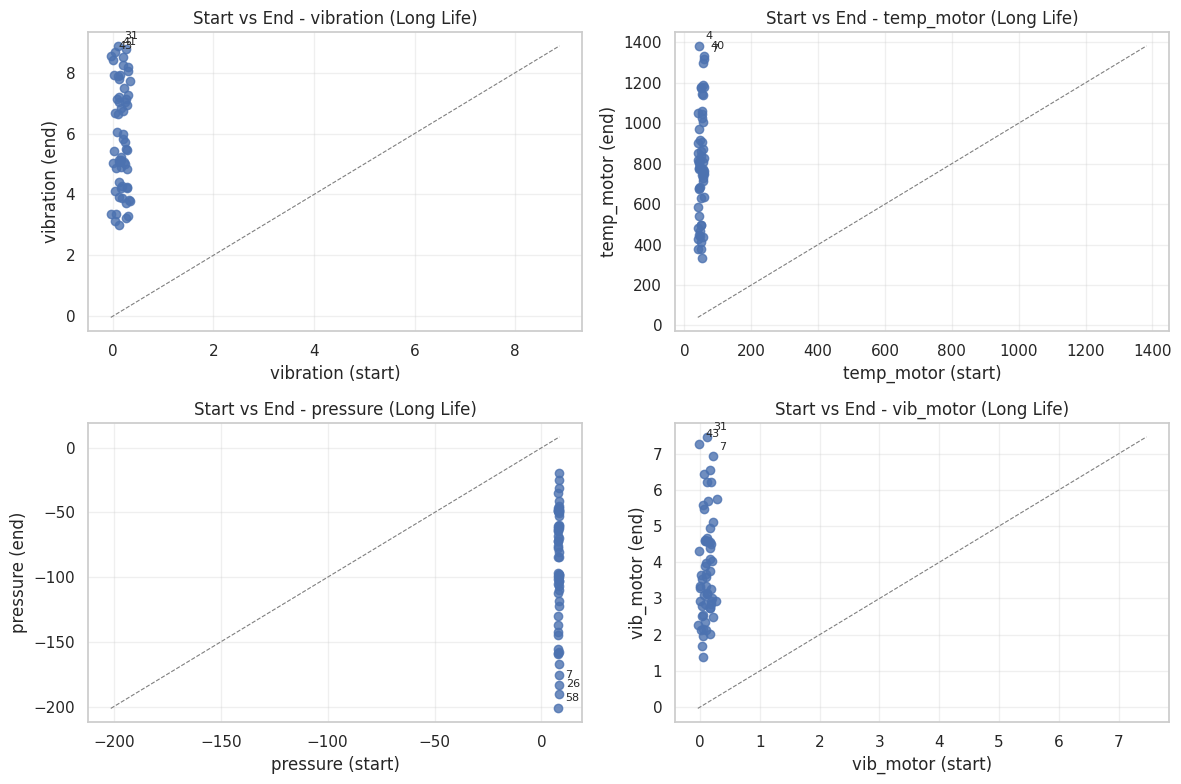


Top 3 cycles with largest increase in vibration (Long Life) (end - start):
    cycle_id  vibration_start  vibration_end  vibration_delta
30        31            0.100          8.877            8.777
40        41            0.052          8.679            8.626
42        43           -0.032          8.555            8.587
Top 3 cycles with largest decrease in vibration (Long Life):
    cycle_id  vibration_start  vibration_end  vibration_delta
34        35            0.125          3.005            2.880
14        15            0.306          3.284            2.979
4          5            0.255          3.243            2.988

Top 3 cycles with largest increase in temp_motor (Long Life) (end - start):
    cycle_id  temp_motor_start  temp_motor_end  temp_motor_delta
3          4            42.981        1382.202          1339.221
39        40            57.819        1333.957          1276.138
6          7            58.884        1318.582          1259.699
Top 3 cycles with largest decr

In [53]:
# 2B/ Cycle comparison: start vs end values per cycle
print("2B/ CYCLE COMPARISONS - start vs end summaries and plots")

# Ensure datasets are loaded
assert 'df_raw_short_life' in globals() and 'df_raw_long_life' in globals(), "Datasets must be defined (run dataset load cells)"


def cycle_comparison(df_raw, title_suffix=""):
    # Sensors to compare
    sensors = ['vibration', 'temp_motor', 'pressure', 'vib_motor']
    available_sensors = [s for s in sensors if s in df_raw.columns]
    if not available_sensors:
        print(f"No sensors found to compare {title_suffix}")
        return
    else:
        print(f"Comparing sensors {title_suffix}: {available_sensors}")

    # Sort and group by cycle
    df_sorted = df_raw.sort_values(['cycle_id', 'time_min'])
    grouped = df_sorted.groupby('cycle_id')

    # Get first and last rows per cycle
    firsts = grouped.first().reset_index()
    lasts = grouped.last().reset_index()

    # Merge start/end values for sensors
    cols_start = ['cycle_id'] + available_sensors
    cols_end = ['cycle_id'] + available_sensors
    start_end = firsts[cols_start].merge(lasts[cols_end], on='cycle_id', suffixes=('_start', '_end'))

    # Compute deltas and percent changes
    for s in available_sensors:
        start_end[f'{s}_delta'] = start_end[f'{s}_end'] - start_end[f'{s}_start']
        start_vals = start_end[f'{s}_start'].replace(0, np.nan)
        start_end[f'{s}_pct_change'] = (start_end[f'{s}_delta'] / start_vals) * 100

    # Print a small example table
    cols_show = ['cycle_id'] + [f'{s}_start' for s in available_sensors] + [f'{s}_end' for s in available_sensors]
    print(f"\nExample start/end table {title_suffix} (first 8 cycles):")
    display(start_end[cols_show].head(8))

    # Summary statistics of deltas
    delta_cols = [f'{s}_delta' for s in available_sensors]
    print(f"\nDelta summary {title_suffix} (end - start):")
    print(start_end[delta_cols].describe().T)

    # Scatter plots start vs end
    n = len(available_sensors)
    rows, cols = 2, 2
    fig, axes = plt.subplots(rows, cols, figsize=(12, 8))
    axes = axes.flatten()
    for i, s in enumerate(available_sensors):
        ax = axes[i]
        x = start_end[f'{s}_start']
        y = start_end[f'{s}_end']
        ax.scatter(x, y, alpha=0.8)
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax.plot(lims, lims, '--', color='gray', linewidth=0.8)
        ax.set_xlabel(f'{s} (start)')
        ax.set_ylabel(f'{s} (end)')
        ax.set_title(f'Start vs End - {s} {title_suffix}')
        ax.grid(alpha=0.3)

        # Annotate top 3 cycles by absolute delta
        top3 = start_end.reindex(start_end[f'{s}_delta'].abs().sort_values(ascending=False).index).head(3)
        for _, row in top3.iterrows():
            ax.annotate(int(row['cycle_id']), (row[f'{s}_start'], row[f'{s}_end']),
                        textcoords='offset points', xytext=(5,5), fontsize=8)
    for j in range(n, rows*cols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

    # Top increasing / decreasing cycles per sensor
    for s in available_sensors:
        print(f"\nTop 3 cycles with largest increase in {s} {title_suffix} (end - start):")
        print(start_end[['cycle_id', f'{s}_start', f'{s}_end', f'{s}_delta']].nlargest(3, f'{s}_delta'))
        print(f"Top 3 cycles with largest decrease in {s} {title_suffix}:")
        print(start_end[['cycle_id', f'{s}_start', f'{s}_end', f'{s}_delta']].nsmallest(3, f'{s}_delta'))

    print_footer(f"Explanatory Data Analysis COMPLETED {title_suffix}")


# Run for both datasets
cycle_comparison(df_raw_short_life, title_suffix="(Short Life)")
cycle_comparison(df_raw_long_life, title_suffix="(Long Life)")

## 3) Train / Validation / Test split

In [54]:
# 3/ DATASET SPLIT - Cycle-based Train / Val / Test 
print_header("3/ DATASET SPLIT - Cycle-based (Leakage-Free)")

def split_datasets(df_raw, N_TRAIN=0, N_VAL=0, N_TEST=0):
    
    df_use = df_raw.copy()

    assert 'cycle_id' in df_use.columns, "cycle_id column is required"

    # Available cycles
    all_cycles = sorted(df_use['cycle_id'].unique())
    n_cycles = len(all_cycles)
    print(f"Total cycles available: {n_cycles}")

    # fall back if generation is changed with out updating splits
    if n_cycles != (N_TRAIN + N_VAL + N_TEST):
        print("Warning: not enough cycles, using proportional split")
        N_TRAIN = int(0.7 * n_cycles)
        N_VAL = int(0.15 * n_cycles)
        N_TEST = n_cycles - N_TRAIN - N_VAL

    # Deterministic split (cycle-id based, not time-based)
    train_cycles = all_cycles[:N_TRAIN]
    val_cycles = all_cycles[N_TRAIN:N_TRAIN + N_VAL]
    test_cycles = all_cycles[N_TRAIN + N_VAL:N_TRAIN + N_VAL + N_TEST]

    print(f"Train cycles ({len(train_cycles)}): {train_cycles}")
    print(f"Val cycles   ({len(val_cycles)}): {val_cycles}")
    print(f"Test cycles  ({len(test_cycles)}): {test_cycles}")

    # Create RAW splits 
    df_train_raw = df_use[df_use['cycle_id'].isin(train_cycles)].copy()
    df_val_raw = df_use[df_use['cycle_id'].isin(val_cycles)].copy()
    df_test_raw = df_use[df_use['cycle_id'].isin(test_cycles)].copy()

    # Sanity checks
    assert set(train_cycles).isdisjoint(val_cycles)
    assert set(train_cycles).isdisjoint(test_cycles)
    assert set(val_cycles).isdisjoint(test_cycles)

    print("\nRow counts (RAW data):")
    print(f"  Train: {df_train_raw.shape[0]} rows")
    print(f"    Val: {df_val_raw.shape[0]} rows")
    print(f"  Test:  {df_test_raw.shape[0]} rows")

    return df_train_raw, df_val_raw, df_test_raw

df_train_raw_short_life, df_val_raw_short_life, df_test_raw_short_life = split_datasets(df_raw_short_life, N_TRAIN=80, N_VAL=20, N_TEST=20)

print("\n" + "="*70 + "\n")

df_train_raw_long_life, df_val_raw_long_life, df_test_raw_long_life = split_datasets(df_raw_long_life, N_TRAIN=40, N_VAL=10, N_TEST=10)

print_footer("DATA SPLIT COMPLETE")


3/ DATASET SPLIT - Cycle-based (Leakage-Free)
Total cycles available: 120
Train cycles (80): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80]
Val cycles   (20): [81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]
Test cycles  (20): [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120]

Row counts (RAW data):
  Train: 35712 rows
    Val: 9062 rows
  Test:  8982 rows


Total cycles available: 60
Train cycles (40): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40]
Val cycles   (10): [41, 42, 43, 44, 45, 46, 47, 48, 49, 50]
Test cycles  (10): [51, 52, 53,


3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions
Dataset         : (Short Life)
Selected sensor : vibration
Train cycles    : 80
Val cycles      : 20
Test cycles     : 20


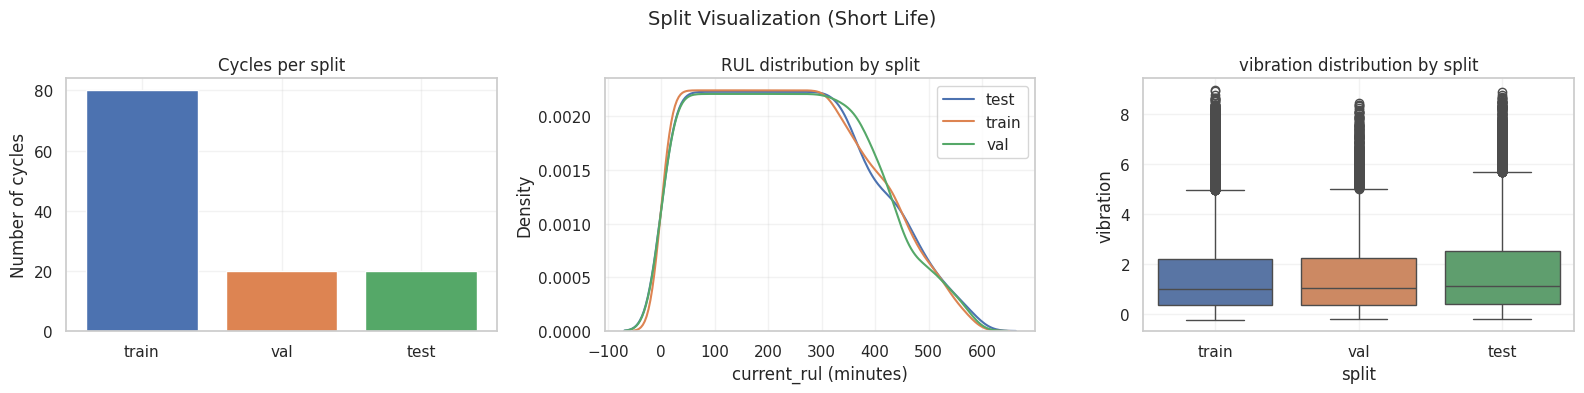


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Short Life)
----------------------------------------------------------------------
Dataset         : (Long Life)
Selected sensor : vibration
Train cycles    : 40
Val cycles      : 10
Test cycles     : 10


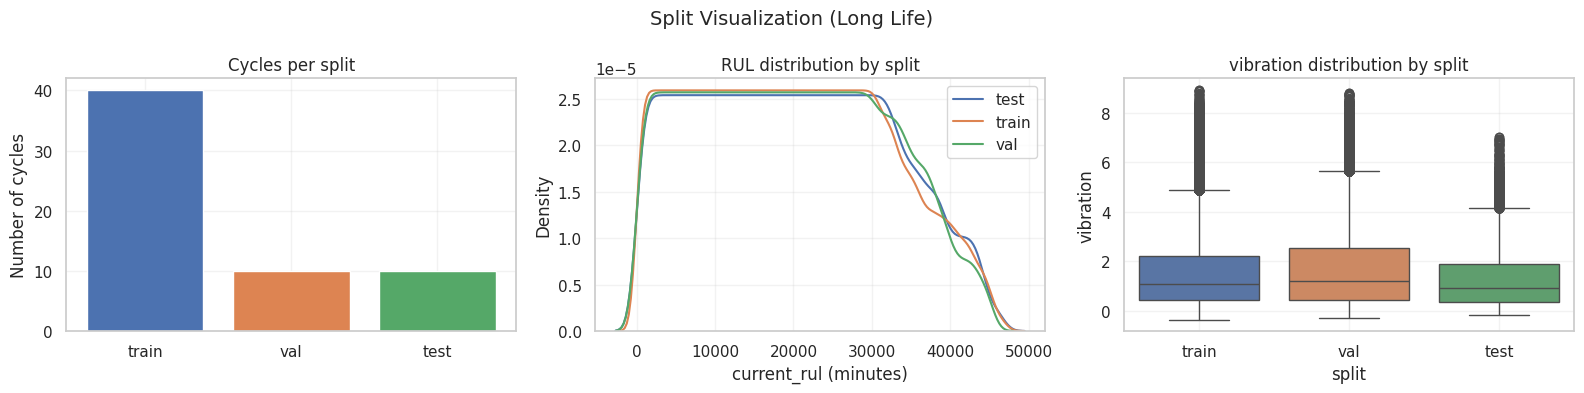


----------------------------------------------------------------------
SPLIT VISUALIZATION COMPLETE (Long Life)
----------------------------------------------------------------------


In [55]:
print_header("3A/ SPLIT VISUALIZATION - cycles, RUL & sensor distributions")

def visualize_splits(df_train, df_val, df_test, title_suffix=""):
    # Ensure RUL is present
    assert 'current_rul' in df_train.columns, "current_rul missing in selected split dataframe"

    # Choose a sensor to visualize (prefer 'vibration' or fallback)
    preferred = 'vibration'
    if preferred in df_train.columns:
        sensor_col = preferred
    else:
        exclude = {'cycle_id', 'time_min', 'timestamp', 'total_rul', 'current_rul'}
        numeric = get_numeric_sensor_cols(df_train, exclude)
        sensor_col = numeric[0] if len(numeric) > 0 else None

    assert sensor_col is not None, "No suitable sensor or feature column found for visualization"

    # Prepare combined dataframe for easy plotting
    def tag_split(df, name):
        d = df[[sensor_col, 'current_rul', 'cycle_id']].copy()
        d['split'] = name
        return d

    plot_df = pd.concat([
        tag_split(df_train, 'train'),
        tag_split(df_val, 'val'),
        tag_split(df_test, 'test')
    ], ignore_index=True)

    print_kv([
        ('Dataset', title_suffix),
        ('Selected sensor', sensor_col),
        ('Train cycles', df_train['cycle_id'].nunique()),
        ('Val cycles', df_val['cycle_id'].nunique()),
        ('Test cycles', df_test['cycle_id'].nunique())
    ])

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    # Cycles per split
    counts = [df_train['cycle_id'].nunique(),
              df_val['cycle_id'].nunique(),
              df_test['cycle_id'].nunique()]
    axes[0].bar(['train', 'val', 'test'], counts,
                color=['#4c72b0', '#dd8452', '#55a868'])
    axes[0].set_title('Cycles per split')
    axes[0].set_ylabel('Number of cycles')
    axes[0].grid(alpha=0.25)

    # RUL distribution (overlayed KDEs)
    for name, grp in plot_df.groupby('split'):
        sns.kdeplot(grp['current_rul'], ax=axes[1], label=name, fill=False)
    axes[1].set_title('RUL distribution by split')
    axes[1].set_xlabel('current_rul (minutes)')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    # Sensor distribution (boxplot)
    sns.boxplot(x='split', y=sensor_col, data=plot_df,
                ax=axes[2], palette=['#4c72b0', '#dd8452', '#55a868'])
    axes[2].set_title(f'{sensor_col} distribution by split')
    axes[2].grid(alpha=0.25)

    plt.suptitle(f"Split Visualization {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

    print_footer(f"SPLIT VISUALIZATION COMPLETE {title_suffix}")


# Run for both datasets
visualize_splits(df_train_raw_short_life, df_val_raw_short_life, df_test_raw_short_life, title_suffix="(Short Life)")
visualize_splits(df_train_raw_long_life, df_val_raw_long_life, df_test_raw_long_life, title_suffix="(Long Life)")

## 4) Feature Engineering

In [56]:
# 4/ FEATURE ENGINEERING - Critical-Aware (Dual Pipeline)
print_header("4/ FEATURE ENGINEERING - Causal & Critical-Aware")

# Ensure datasets are loaded
assert 'df_train_raw_long_life' in globals()
assert 'df_train_raw_short_life' in globals()

SENSORS = ['vibration', 'temp_motor', 'pressure', 'vib_motor']
WINDOW_SHORT = 5
WINDOW_LONG = 20

def engineer_features(df):
    """
    Applies rolling windows, interaction terms, and critical-aware features.
    Works for both Long-Life and Short-Life datasets identically.
    """
    df_feat = df.copy()
    df_feat = df_feat.sort_values(['cycle_id', 'time_min']).reset_index(drop=True)
    grouped = df_feat.groupby('cycle_id')
    
    # Original rolling features
    for s in SENSORS:
        # Short rolling mean
        df_feat[f"{s}_roll_mean_{WINDOW_SHORT}"] = (
                                                        grouped[s].rolling(window=WINDOW_SHORT, min_periods=1).mean()
                                                        .reset_index(level=0, drop=True)
                                                    )
        # Long rolling mean
        df_feat[f"{s}_roll_mean_{WINDOW_LONG}"] = (
                                                    grouped[s].rolling(window=WINDOW_LONG, min_periods=1).mean()
                                                    .reset_index(level=0, drop=True)
                                                )
        # Long rolling std (volatility)
        df_feat[f"{s}_roll_std_{WINDOW_LONG}"] = (
                                                    grouped[s].rolling(window=WINDOW_LONG, min_periods=2).std()
                                                    .reset_index(level=0, drop=True).fillna(0)
                                                )
        # Deviation from long-term mean
        df_feat[f"{s}_dev_long"] = df_feat[s] - df_feat[f"{s}_roll_mean_{WINDOW_LONG}"]
        
        # Slope (Trend) calculation
        df_feat[f"{s}_slope_{WINDOW_LONG}"] = (
                                                grouped[f"{s}_roll_mean_{WINDOW_LONG}"].diff(WINDOW_LONG).fillna(0)
                                            )
    
    # Interaction features (Physical coupling)
    with np.errstate(divide='ignore', invalid='ignore'):
        coupling = (df_feat['vib_motor'] / df_feat['vibration']).replace([np.inf, -np.inf], np.nan)
    df_feat['motor_pump_coupling'] = coupling.fillna(1.0).clip(0, 10)
    
    # Energy features
    df_feat['vibration_energy'] = (
                                    grouped['vibration'].rolling(window=WINDOW_SHORT, min_periods=1).mean()
                                    .reset_index(level=0, drop=True) ** 2
                                )
    
    # Stability indicators
    pressure_std = df_feat['pressure_roll_std_20'].replace(0, 1e-6)
    df_feat['pressure_stability'] = 1.0 / pressure_std
    
    # Critical aware features:
    # Acceleration features (rate of change of slope)
    for s in ['vibration', 'temp_motor']:
        df_feat[f"{s}_acceleration"] = grouped[f"{s}_slope_{WINDOW_LONG}"].diff(5).fillna(0)
    
    # Volatility surge (sudden std increase vs long term)
    for s in SENSORS:
        roll_std_short = grouped[s].rolling(window=5, min_periods=2).std().reset_index(level=0, drop=True)
        df_feat[f"{s}_volatility_surge"] = roll_std_short - df_feat[f"{s}_roll_std_{WINDOW_LONG}"]
    
    # Multi-sensor degradation indicator (Normalized locally)
    vib_norm = (df_feat['vibration'] - df_feat['vibration'].min()) / (df_feat['vibration'].max() - df_feat['vibration'].min() + 1e-6)
    temp_norm = (df_feat['temp_motor'] - df_feat['temp_motor'].min()) / (df_feat['temp_motor'].max() - df_feat['temp_motor'].min() + 1e-6)
    pressure_inv = 1 - (df_feat['pressure'] - df_feat['pressure'].min()) / (df_feat['pressure'].max() - df_feat['pressure'].min() + 1e-6)
    
    df_feat['degradation_index'] = (vib_norm + temp_norm + pressure_inv) / 3
    
    # Recent max features (captures spikes)
    for s in ['vibration', 'vib_motor']:
        df_feat[f"{s}_max_10"] = grouped[s].rolling(window=10, min_periods=1).max().reset_index(level=0, drop=True)
    
    # Clean up (Fill NaNs caused by diff/rolling)
    for col in df_feat.columns:
        if col in ['cycle_id', 'time_min', 'current_rul', 'total_rul', 'timestamp']:
            continue
        df_feat[col] = grouped[col].transform(lambda x: x.ffill().bfill())
    
    df_feat.replace([np.inf, -np.inf], 0, inplace=True)
    df_feat.fillna(0, inplace=True)
    
    return df_feat

# PIPELINE 1 - SHORT LIFE (For Two-Stage Models)
print("\n--- Processing SHORT LIFE Dataset (For Stage 1 & 2 Models) ---")
df_train_short = engineer_features(df_train_raw_short_life)
df_val_short   = engineer_features(df_val_raw_short_life)
df_test_short  = engineer_features(df_test_raw_short_life)

# Sanity check Short
assert df_train_short.shape[0] == df_train_raw_short_life.shape[0]
assert df_val_short.shape[0] == df_val_raw_short_life.shape[0]
assert df_test_short.shape[0] == df_test_raw_short_life.shape[0]

# PIPELINE 2 - LONG LIFE (For Base Model)
print("\n--- Processing LONG LIFE Dataset (Base Model) ---")
df_train_long = engineer_features(df_train_raw_long_life)
df_val_long   = engineer_features(df_val_raw_long_life)
df_test_long  = engineer_features(df_test_raw_long_life)

# Sanity check Long
assert df_train_long.shape[0] == df_train_raw_long_life.shape[0]
assert df_val_long.shape[0] == df_val_raw_long_life.shape[0]
assert df_test_long.shape[0] == df_test_raw_long_life.shape[0]

# SUMMARY
new_features = sorted(set(df_train_short.columns) - set(df_train_raw_short_life.columns))

print(f"\nFeature engineering summary:")
print(f"  New features created: {len(new_features)}")
print(f"  Short Life Train: {df_train_short.shape} | Long Life Train: {df_train_long.shape}")
print(f"  Sample features: {new_features[:5]}")

print_footer("FEATURE ENGINEERING COMPLETE")


4/ FEATURE ENGINEERING - Causal & Critical-Aware

--- Processing SHORT LIFE Dataset (For Stage 1 & 2 Models) ---

--- Processing LONG LIFE Dataset (Base Model) ---

Feature engineering summary:
  New features created: 32
  Short Life Train: (35712, 41) | Long Life Train: (1542937, 41)
  Sample features: ['degradation_index', 'motor_pump_coupling', 'pressure_dev_long', 'pressure_roll_mean_20', 'pressure_roll_mean_5']

----------------------------------------------------------------------
FEATURE ENGINEERING COMPLETE
----------------------------------------------------------------------


## 5) Feature Selection

In [57]:
# 5/ FEATURE SELECTION - Correlation + XGBoost Importance (Targeted for Dual Pipeline)
print_header("5/ FEATURE SELECTION - Short-Life Targeted Analysis")


# Preconditions
assert 'df_train_short' in globals(), "Run feature engineering for Short-Life first"
assert 'df_train_long' in globals(), "Run feature engineering for Long-Life first"

# Define target and columns to ignore
TARGET_COL = 'current_rul'
EXCLUDE_COLS = {'cycle_id', 'time_min', 'timestamp', 'total_rul', TARGET_COL}

# Identify numeric feature candidates from the short-life set
feature_cols = [
                    c for c in df_train_short.columns
                    if c not in EXCLUDE_COLS and pd.api.types.is_numeric_dtype(df_train_short[c])
                ]

print(f"Initial number of features: {len(feature_cols)}")

# Extract X, y from Short-Life Train (The most informative set for degradation)
X_train_fs = df_train_short[feature_cols].fillna(0)
y_train_fs = df_train_short[TARGET_COL]

# Correlation-based filtering
print("\nCorrelation-based filtering...")

corr_matrix = X_train_fs.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

corr_threshold = 0.90
to_drop = [col for col in upper.columns if any(upper[col] > corr_threshold)]

print(f"Highly correlated features to drop: {len(to_drop)}")

features_after_corr = [f for f in feature_cols if f not in to_drop]
print(f"Remaining features after correlation filter: {len(features_after_corr)}")

# Importance-based selection using XGBoost
print("\nXGBoost feature importance (on Short-Life data)...")

X_imp = X_train_fs[features_after_corr]

importance_model = XGBRegressor(
                                    n_estimators=200,
                                    max_depth=5,
                                    learning_rate=0.1,
                                    subsample=0.8,
                                    colsample_bytree=0.8,
                                    random_state=42,
                                    n_jobs=-1,
                                    verbosity=0
                                )

importance_model.fit(X_imp, y_train_fs)

importances = pd.Series(
                            importance_model.feature_importances_,
                            index=features_after_corr
                        ).sort_values(ascending=False)

print("Top 15 features by importance:")
for i, (feat, val) in enumerate(importances.head(15).items(), 1):
    print(f"  {i:2d}. {feat:35s} {val:.4f}")

# Select top-N features
top_n = 20
selected_features = importances.head(top_n).index.tolist()

# Save selected features list to JSON
cache_file = os.path.join(save_path, "selected_process_pump_features.json")
with open(cache_file, 'w') as f:
    json.dump(selected_features, f, indent=4)

print(f"\nSelected top {top_n} features saved to: {cache_file}")

# Final Split Preparation (Applying selection to both datasets)
print("\nBuilding final X, y for Short and Long pipelines...")

# Final Short Life Sets (For Two-Stage Models)
X_train_short = df_train_short[selected_features]
y_train_short = df_train_short[TARGET_COL]
X_val_short   = df_val_short[selected_features]
y_val_short   = df_val_short[TARGET_COL]
X_test_short  = df_test_short[selected_features]
y_test_short  = df_test_short[TARGET_COL]

# Final Long Life Sets (For Base Model)
X_train_long = df_train_long[selected_features]
y_train_long = df_train_long[TARGET_COL]
X_val_long   = df_val_long[selected_features]
y_val_long   = df_val_long[TARGET_COL]
X_test_long  = df_test_long[selected_features]
y_test_long  = df_test_long[TARGET_COL]

# Validation
assert len(selected_features) > 0, "No features selected"
assert X_train_short.shape[1] == X_train_long.shape[1], "Pipeline feature mismatch"

print(f"\nFinal feature count: {len(selected_features)}")
print(f"Final Shapes Summary:")
print(f"  Short-Life Train: {X_train_short.shape}  | Target: {y_train_short.shape}")
print(f"  Long-Life Train : {X_train_long.shape}   | Target: {y_train_long.shape}")

print_footer("FEATURE SELECTION COMPLETE")


5/ FEATURE SELECTION - Short-Life Targeted Analysis
Initial number of features: 36

Correlation-based filtering...
Highly correlated features to drop: 15
Remaining features after correlation filter: 21

XGBoost feature importance (on Short-Life data)...
Top 15 features by importance:
   1. vibration                           0.4808
   2. degradation_index                   0.1086
   3. vibration_volatility_surge          0.0929
   4. vibration_roll_std_20               0.0820
   5. temp_motor_slope_20                 0.0559
   6. vib_motor_dev_long                  0.0286
   7. vibration_dev_long                  0.0223
   8. pressure_stability                  0.0218
   9. temp_motor                          0.0204
  10. pressure_roll_std_20                0.0177
  11. pressure                            0.0146
  12. pressure_slope_20                   0.0128
  13. temp_motor_roll_std_20              0.0118
  14. motor_pump_coupling                 0.0087
  15. temp_motor_acceleratio

## 6) Model Training (XGBoost)

In [58]:
# 6/ MODEL TRAINING - Optimized XGBoost for RUL Prediction
print_header("6/ MODEL TRAINING - Optimized XGBoost for RUL Prediction")

# Validate preconditions
assert 'selected_features' in globals(), "Feature selection not found. Run #5 first."
assert 'X_train_long' in globals() and 'y_train_long' in globals(), "Training data missing. Run #5 first."
assert 'X_val_long' in globals() and 'y_val_long' in globals(), "Validation data missing. Run #5 first."
assert 'X_test_long' in globals() and 'y_test_long' in globals(), "Test data missing. Run #5 first."

print(f"     Train set: {X_train_long.shape}")
print(f"Validation set: {X_val_long.shape}")
print(f"      Test set: {X_test_long.shape}")

# Initialize model with enhanced parameters
base_model = XGBRegressor(
                        n_estimators=800,
                        max_depth=5,
                        learning_rate=0.02,
                        min_child_weight=3,
                        subsample=0.7,
                        colsample_bytree=0.7,
                        gamma=0.1,
                        reg_alpha=0.1,
                        reg_lambda=1.0,
                        objective='reg:squarederror',
                        random_state=42,
                        n_jobs=-1,
                        tree_method='hist'
                    )

# Define adaptive sample weights with progressive scaling
print("\nTraining model with adaptive weighting...")

sample_weights = np.ones_like(y_train_long)
sample_weights[y_train_long <= 500] = 2.0
sample_weights[y_train_long <= 100] = 3.0

# Train with validation monitoring
base_model.fit(
            X_train_long,
            y_train_long,
            sample_weight=sample_weights,
            eval_set=[(X_val_long, y_val_long)],
            eval_metric='mae',
            early_stopping_rounds=100,
            verbose=50
        )

print(f"\nTraining complete. Best iteration: {base_model.best_iteration}")

# Generate predictions
y_val_pred = base_model.predict(X_val_long)
y_test_pred = base_model.predict(X_test_long)

# Ensure predictions are within valid range
MAX_RUL = 48000
y_val_pred = np.clip(y_val_pred, 0, MAX_RUL)
y_test_pred = np.clip(y_test_pred, 0, MAX_RUL)

# Calculate evaluation metrics
val_mae = MAE(y_val_long, y_val_pred)
val_rmse = R_MSE(y_val_long, y_val_pred)
val_r2 = r2_score(y_val_long, y_val_pred)

test_mae = MAE(y_test_long, y_test_pred)
test_rmse = R_MSE(y_test_long, y_test_pred)
test_r2 = r2_score(y_test_long, y_test_pred)

print("\nMODEL PERFORMANCE:")
print(f"Validation - MAE: {val_mae:.2f}, RMSE: {val_rmse:.2f}, R^2: {val_r2:.4f}")
print(f"Test       - MAE: {test_mae:.2f}, RMSE: {test_rmse:.2f}, R^2: {test_r2:.4f}")

# Critical region analysis
print("\nCRITICAL REGION ANALYSIS (RUL <= 20):")

for set_name, y_true, y_pred in [('Validation', y_val_long, y_val_pred), ('Test', y_test_long, y_test_pred)]:
    critical_mask = y_true <= 20
    n_critical = critical_mask.sum()
    
    if n_critical == 0:
        print(f"{set_name}: No critical samples found")
        continue
    
    critical_mae = MAE(y_true[critical_mask], y_pred[critical_mask])
    accuracy_10min = (np.abs(y_true[critical_mask] - y_pred[critical_mask]) <= 10).mean() * 100
    
    print("-" * 40)
    print(f"\n{set_name}:")
    print(f"              Samples: {n_critical}")
    print(f"                  MAE: {critical_mae:.2f}")
    print(f"  Accuracy (+/-10min): {accuracy_10min:.1f}%")

# save model as json
base_model.save_model(f"{save_path}process_pump_base_model.json")
print(f"Model saved: {save_path}process_pump_base_model.json")


print_footer("MODEL TRAINING COMPLETED")


6/ MODEL TRAINING - Optimized XGBoost for RUL Prediction
     Train set: (1542937, 20)
Validation set: (388912, 20)
      Test set: (393604, 20)

Training model with adaptive weighting...
[0]	validation_0-mae:9822.61774
[50]	validation_0-mae:4949.77734
[100]	validation_0-mae:4288.83459
[150]	validation_0-mae:4418.37566
[200]	validation_0-mae:4635.11426
[202]	validation_0-mae:4645.46459

Training complete. Best iteration: 102

MODEL PERFORMANCE:
Validation - MAE: 4285.77, RMSE: 5327.37, R^2: 0.7928
Test       - MAE: 3788.45, RMSE: 4629.30, R^2: 0.8485

CRITICAL REGION ANALYSIS (RUL <= 20):
----------------------------------------

Validation:
              Samples: 210
                  MAE: 3606.24
  Accuracy (+/-10min): 0.0%
----------------------------------------

Test:
              Samples: 210
                  MAE: 3996.79
  Accuracy (+/-10min): 0.0%
Model saved: models_and_features/process_pump/process_pump_base_model.json

-----------------------------------------------------

## 7) Model Evaluation

In [59]:
# 7/ MODEL EVALUATION - BASE MODEL PERFORMANCE (LONG-LIFE FOCUS)
print_header("MODEL EVALUATION - Base Model Long-Life Analysis")

# Preconditions check
assert 'y_test_long' in globals() and 'y_test_pred' in globals()

# OVERALL PERFORMANCE 
print("\n=== OVERALL PERFORMANCE (0 - 48,000 min) ===")

val_mae  = MAE(y_val_long, y_val_pred)
val_rmse = R_MSE(y_val_long, y_val_pred)
val_r2   = r2_score(y_val_long, y_val_pred)

test_mae  = MAE(y_test_long, y_test_pred)
test_rmse = R_MSE(y_test_long, y_test_pred)
test_r2   = r2_score(y_test_long, y_test_pred)

print("\nVALIDATION (Long Life):")
print(f"   MAE: {val_mae:.2f} min")
print(f"  RMSE: {val_rmse:.2f}")
print(f"   R^2: {val_r2:.4f}")

print("\nTEST (Long Life):")
print(f"   MAE: {test_mae:.2f} min")
print(f"  RMSE: {test_rmse:.2f}")
print(f"   R^2: {test_r2:.4f}")

# RUL-STRATIFIED ANALYSIS (LONG-LIFE BINS)
# Reflect the 48,000 min scale
print("\n=== RUL STRATIFIED ANALYSIS (TEST SET) ===")

# Ranges wider to represent long-term planning
bins = [(0, 100), (100, 1000), (1000, 10000), (10000, 30000), (30000, 50000)]
labels = ["Near Critical", "Short Term", "Mid Term", "Long Term", "Initial/Healthy"]

print(f"{'Range':<18s} {'N':>8s} {'MAE':>10s} {'Error %':>10s}")
print("-" * 55)

for (low, high), label in zip(bins, labels):
    mask = (y_test_long >= low) & (y_test_long < high)
    if mask.sum() == 0:
        continue
    
    mae = MAE(y_test_long[mask], y_test_pred[mask])
    # Relative error is more meaningful for large numbers
    avg_true = y_test_long[mask].mean()
    rel_error = (mae / avg_true) * 100 if avg_true > 0 else 0
    
    print(f"{label:<18s} {mask.sum():8d} {mae:10.2f} {rel_error:9.1f}%")

# CRITICAL REGION DIAGNOSTIC (EXPECTED TO BE LOW FOR BASE MODEL)
print("\n=== CRITICAL REGION DIAGNOSTIC (RUL <= 100) ===")
# Note: Base model is NOT expected to be accurate here, this is Stage-2's job.

crit_mask = y_test_long <= 100
n_crit = crit_mask.sum()

if n_crit > 0:
    crit_mae = MAE(y_test_long[crit_mask], y_test_pred[crit_mask])
    print(f"  Samples found: {n_crit}")
    print(f"  Base Model MAE in Critical Zone: {crit_mae:.2f} min")
    print("  Interpretation: High error expected. Stage-1/2 will handle this region.")
else:
    print("  No critical samples in test set.")

# BASE MODEL QUALITY CHECK (PLANNING FOCUS)
print("\n=== BASE MODEL QUALITY CHECK ===")

# Overall Trend (>80% accuracy target)
req1_pass = test_r2 >= 0.80 
# Relative Error for Mid/Long term should be acceptable (< 15%)
mid_long_mask = y_test_long > 1000
mid_long_mae = MAE(y_test_long[mid_long_mask], y_test_pred[mid_long_mask])
mid_long_avg = y_test_long[mid_long_mask].mean()
rel_err_mid = (mid_long_mae / mid_long_avg) * 100
req2_pass = rel_err_mid <= 15.0

print(f"  Overall R^2 >= 80%      : {'PASS' if req1_pass else 'FAIL'} ({test_r2 * 100:.1f}%)")
print(f"  Mid/Long Term Err < 15% : {'PASS' if req2_pass else 'FAIL'} ({rel_err_mid:.1f}%)")
print("\nFinal Decision: Base Model is suitable for Long-Term Planning.")

print_footer("BASE MODEL EVALUATION COMPLETE")


MODEL EVALUATION - Base Model Long-Life Analysis

=== OVERALL PERFORMANCE (0 - 48,000 min) ===

VALIDATION (Long Life):
   MAE: 4285.77 min
  RMSE: 5327.37
   R^2: 0.7928

TEST (Long Life):
   MAE: 3788.45 min
  RMSE: 4629.30
   R^2: 0.8485

=== RUL STRATIFIED ANALYSIS (TEST SET) ===
Range                     N        MAE    Error %
-------------------------------------------------------
Near Critical          1000    4752.77    9601.6%
Short Term             9000    6842.61    1245.2%
Mid Term              90000    3991.40      72.6%
Long Term            200000    2818.76      14.1%
Initial/Healthy       93604    5361.24      14.9%

=== CRITICAL REGION DIAGNOSTIC (RUL <= 100) ===
  Samples found: 1010
  Base Model MAE in Critical Zone: 4776.02 min
  Interpretation: High error expected. Stage-1/2 will handle this region.

=== BASE MODEL QUALITY CHECK ===
  Overall R^2 >= 80%      : PASS (84.9%)
  Mid/Long Term Err < 15% : FAIL (18.1%)

Final Decision: Base Model is suitable for Long-T


7A/ VISUALIZATION - Predictions vs True RUL


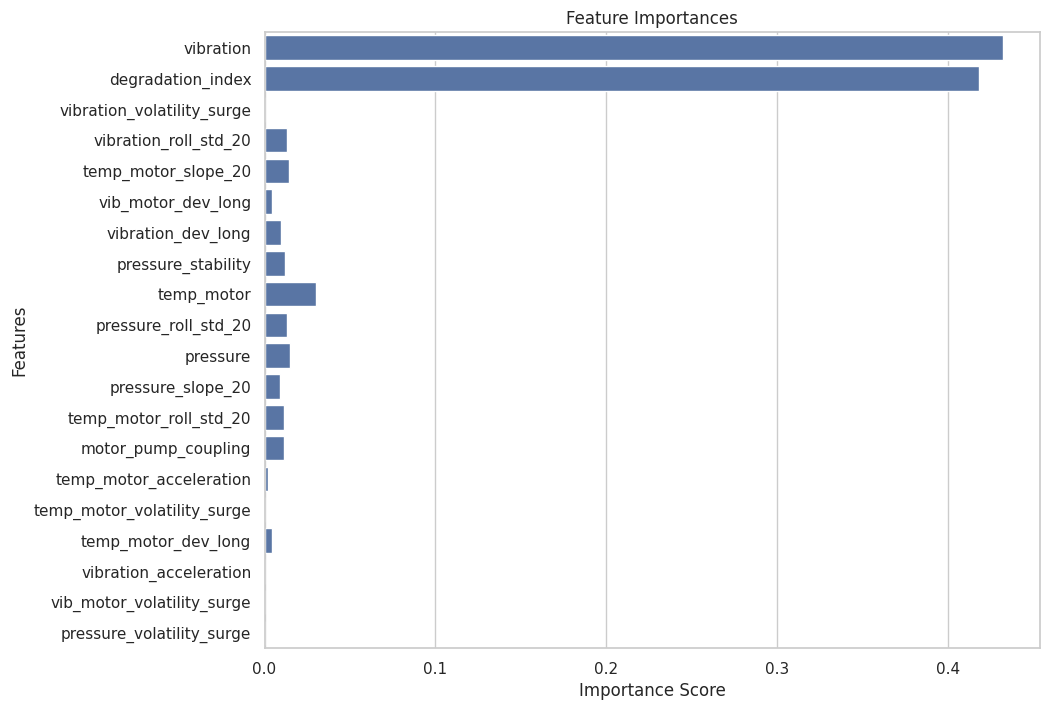

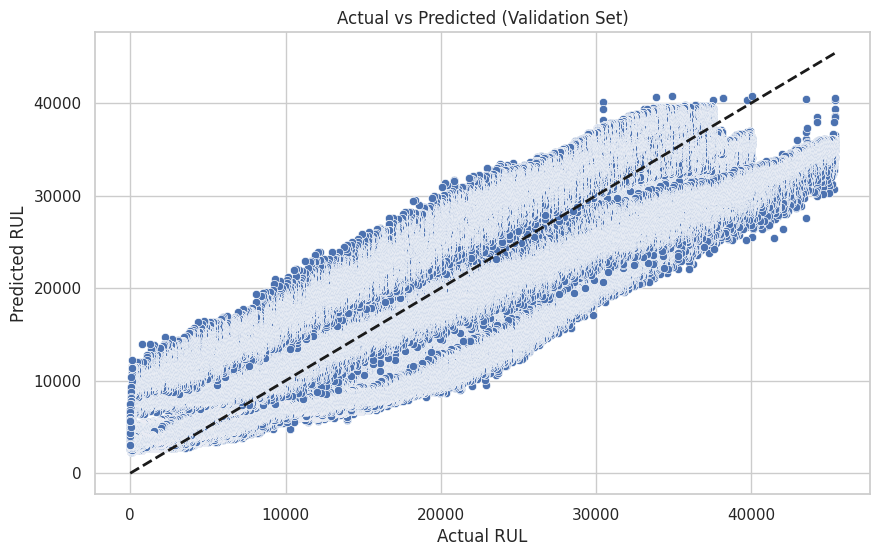

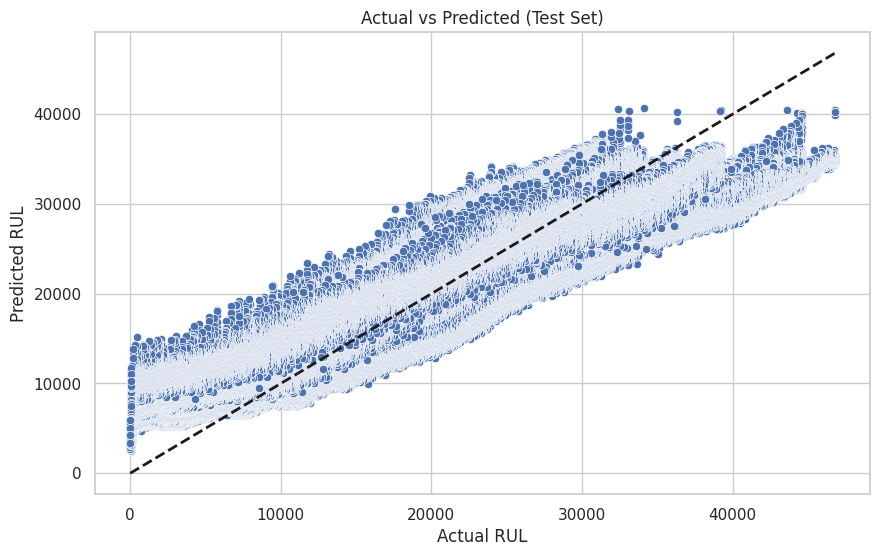

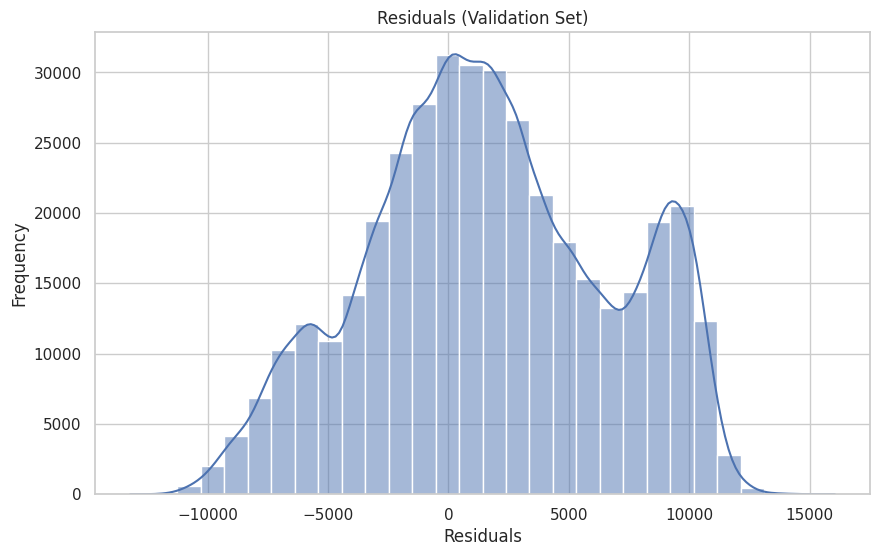

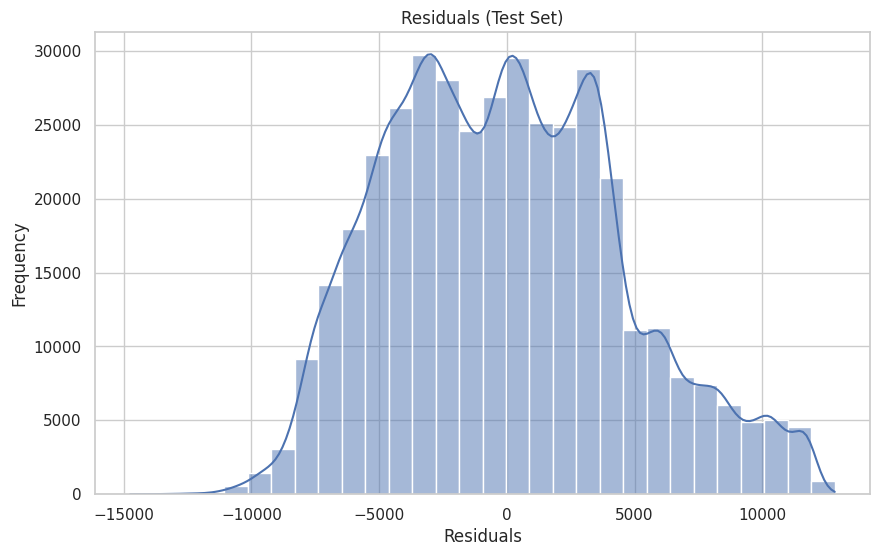

In [60]:
# 7A/ VISUALIZATION - Predictions vs True RUL

print_header("7A/ VISUALIZATION - Predictions vs True RUL")

# Function to plot feature importance
def plot_feature_importance(model, features):
    plt.figure(figsize=(10, 8))
    sns.barplot(x=model.feature_importances_, y=features)
    plt.title('Feature Importances')
    plt.xlabel('Importance Score')
    plt.ylabel('Features')
    plt.show()

# Function to plot actual vs predicted values
def plot_actual_vs_predicted(y_true, y_pred, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_true, y=y_pred)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    plt.title(title)
    plt.xlabel('Actual RUL')
    plt.ylabel('Predicted RUL')
    plt.show()

# Function to plot residuals
def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(10, 6))
    sns.histplot(residuals, bins=30, kde=True)
    plt.title(title)
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.show()

# Plot feature importances
plot_feature_importance(base_model, selected_features)

# Plot actual vs predicted values for validation set
plot_actual_vs_predicted(y_val_long, y_val_pred, 'Actual vs Predicted (Validation Set)')

# Plot actual vs predicted values for test set
plot_actual_vs_predicted(y_test_long, y_test_pred, 'Actual vs Predicted (Test Set)')

# Plot residuals for validation set
plot_residuals(y_val_long, y_val_pred, 'Residuals (Validation Set)')

# Plot residuals for test set
plot_residuals(y_test_long, y_test_pred, 'Residuals (Test Set)')

## 8) Two Stage Models

### 8.1) STAGE 1 - Critical Region Classification

In [61]:
# 8/ GATEKEEPER MODEL

# STAGE 1 — Critical Region Classification (RUL <= 100)

# Preconditions
assert 'X_train_short' in globals() and 'y_train_short' in globals()
assert 'X_val_short' in globals() and 'y_val_short' in globals()
assert 'X_test_short' in globals() and 'y_test_short' in globals()
assert 'selected_features' in globals()

print_header("STAGE 1 - Critical Region Detector")

# Binary target
CRITICAL_LIMIT = 100
y_train_crit = (y_train_short <= CRITICAL_LIMIT).astype(int)
y_val_crit   = (y_val_short   <= CRITICAL_LIMIT).astype(int)
y_test_crit  = (y_test_short  <= CRITICAL_LIMIT).astype(int)

print("Critical ratio:")
print(f"Train: {y_train_crit.mean()*100:.2f}%")
print(f"Val  : {y_val_crit.mean()*100:.2f}%")
print(f"Test : {y_test_crit.mean()*100:.2f}%")

# Compute scale_pos_weight
neg, pos = np.bincount(y_train_crit)
scale_pos_weight = neg / pos

print(f"scale_pos_weight = {scale_pos_weight:.1f}")

stage1_classifier = XGBClassifier(
                                    n_estimators=400,
                                    max_depth=4,
                                    learning_rate=0.05,
                                    subsample=0.8,
                                    colsample_bytree=0.8,
                                    min_child_weight=5,
                                    gamma=0.2,
                                    scale_pos_weight=scale_pos_weight,
                                    objective="binary:logistic",
                                    eval_metric="logloss",
                                    random_state=42,
                                    n_jobs=-1,
                                    tree_method="hist"
                                )

stage1_classifier.fit(
                        X_train_short,
                        y_train_crit,
                        eval_set=[(X_val_short, y_val_crit)],
                        early_stopping_rounds=50,
                        verbose=50
                    )

# Predict probabilities
val_probs = stage1_classifier.predict_proba(X_val_short)[:, 1]

# Conservative threshold to not miss critical moments
THRESH = 0.3
val_pred = (val_probs >= THRESH).astype(int)

print("\nVALIDATION PERFORMANCE (Threshold = 0.3)")
print(confusion_matrix(y_val_crit, val_pred))
print(classification_report(y_val_crit, val_pred, digits=3))

test_probs = stage1_classifier.predict_proba(X_test_short)[:, 1]
test_pred = (test_probs >= THRESH).astype(int)

print("\nTEST PERFORMANCE (Threshold = 0.3)")
print(confusion_matrix(y_test_crit, test_pred))
print(classification_report(y_test_crit, test_pred, digits=3))

# save model
stage1_classifier.save_model(f"{save_path}process_pump_stage1_classifier.json")
print(f"Model saved: {save_path}process_pump_stage1_classifier.json")


print_footer("STAGE 1 COMPLETE")



STAGE 1 - Critical Region Detector
Critical ratio:
Train: 22.63%
Val  : 22.29%
Test : 22.49%
scale_pos_weight = 3.4
[0]	validation_0-logloss:0.65310
[50]	validation_0-logloss:0.14496
[100]	validation_0-logloss:0.11064
[150]	validation_0-logloss:0.10658
[200]	validation_0-logloss:0.10784
[201]	validation_0-logloss:0.10776

VALIDATION PERFORMANCE (Threshold = 0.3)
[[6414  628]
 [  75 1945]]
              precision    recall  f1-score   support

           0      0.988     0.911     0.948      7042
           1      0.756     0.963     0.847      2020

    accuracy                          0.922      9062
   macro avg      0.872     0.937     0.897      9062
weighted avg      0.937     0.922     0.926      9062


TEST PERFORMANCE (Threshold = 0.3)
[[5986  976]
 [  43 1977]]
              precision    recall  f1-score   support

           0      0.993     0.860     0.922      6962
           1      0.669     0.979     0.795      2020

    accuracy                          0.887      8982

### 8.2) STAGE 2A - Critical Regression

In [62]:
# 8A/ STAGE 2A - Critical Regressor (RUL <= 50)
print_header("8A/ STAGE 2A - Critical Region Regressor (RUL <= 50)")

# Preconditions
assert 'X_train_short' in globals() and 'y_train_short' in globals()
assert 'X_val_short' in globals() and 'y_val_short' in globals()
assert 'X_test_short' in globals() and 'y_test_short' in globals()
assert 'selected_features' in globals()

# Select critical samples
CRITICAL_MAX_RUL = 100

train_mask = y_train_short <= CRITICAL_MAX_RUL
val_mask   = y_val_short   <= CRITICAL_MAX_RUL
test_mask  = y_test_short  <= CRITICAL_MAX_RUL

X_train_c = X_train_short.loc[train_mask, selected_features]
y_train_c = y_train_short.loc[train_mask]

X_val_c = X_val_short.loc[val_mask, selected_features]
y_val_c = y_val_short.loc[val_mask]

X_test_c = X_test_short.loc[test_mask, selected_features]
y_test_c = y_test_short.loc[test_mask]

print(f"Critical samples:")
print(f"  Train: {len(X_train_c)}")
print(f"    Val: {len(X_val_c)}")
print(f"   Test: {len(X_test_c)}")

assert len(X_train_c) > 0, "No critical training samples"

# Strong focus on low RUL
sample_weights_c = np.ones_like(y_train_c)
sample_weights_c[y_train_c <= 50] = 2.0
sample_weights_c[y_train_c <= 20] = 4.0
sample_weights_c[y_train_c <= 10] = 8.0

# Model optimized for local accuracy
stage2a_regressor  = XGBRegressor(
                                    n_estimators=600,
                                    max_depth=4,
                                    learning_rate=0.03,
                                    min_child_weight=1,
                                    subsample=0.9,
                                    colsample_bytree=0.9,
                                    gamma=0.0,
                                    reg_alpha=0.0,
                                    reg_lambda=1.0,
                                    objective="reg:squarederror",
                                    random_state=42,
                                    n_jobs=-1,
                                    tree_method="hist"
                                )

stage2a_regressor.fit(
                        X_train_c,
                        y_train_c,
                        sample_weight=sample_weights_c,
                        eval_set=[(X_val_c, y_val_c)],
                        eval_metric="mae",
                        early_stopping_rounds=80,
                        verbose=50
                    )

print(f"\nBest iteration: {stage2a_regressor.best_iteration}")

# Evaluation
y_val_pred_c  = stage2a_regressor.predict(X_val_c)
y_test_pred_c = stage2a_regressor.predict(X_test_c)

val_mae_c  = MAE(y_val_c, y_val_pred_c)
test_mae_c = MAE(y_test_c, y_test_pred_c)

val_acc10  = (np.abs(y_val_c - y_val_pred_c) <= 10).mean() * 100
test_acc10 = (np.abs(y_test_c - y_test_pred_c) <= 10).mean() * 100

print("\nCRITICAL REGRESSOR PERFORMANCE:")
print(f"Validation - MAE: {val_mae_c:.2f}, +/-10min: {val_acc10:.1f}%")
print(f"      Test - MAE: {test_mae_c:.2f}, +/-10min: {test_acc10:.1f}%")


# save model
stage2a_regressor.save_model(f"{save_path}process_pump_stage2a_regressor.json")
print(f"Model saved: {save_path}process_pump_stage2a_regressor.json")



print_footer("STAGE 2A COMPLETE")



8A/ STAGE 2A - Critical Region Regressor (RUL <= 50)
Critical samples:
  Train: 8080
    Val: 2020
   Test: 2020
[0]	validation_0-mae:29.03927
[50]	validation_0-mae:17.03465
[100]	validation_0-mae:14.36226
[150]	validation_0-mae:14.00108
[200]	validation_0-mae:13.97475
[237]	validation_0-mae:14.06207

Best iteration: 157

CRITICAL REGRESSOR PERFORMANCE:
Validation - MAE: 13.97, +/-10min: 45.0%
      Test - MAE: 14.10, +/-10min: 44.8%
Model saved: models_and_features/process_pump/process_pump_stage2a_regressor.json

----------------------------------------------------------------------
STAGE 2A COMPLETE
----------------------------------------------------------------------


### 8.3) STAGE 2B - Ultra-Critical Regressor

In [63]:
# 8B/ STAGE 2B - Ultra-Critical Regressor (RUL <= 20)
print_header("8B/ STAGE 2B - Ultra-Critical Regressor (RUL <= 20)")

# Preconditions
assert 'X_train_short' in globals() and 'y_train_short' in globals()
assert 'X_val_short' in globals() and 'y_val_short' in globals()
assert 'X_test_short' in globals() and 'y_test_short' in globals()
assert 'selected_features' in globals()

# Filter ultra-critical samples (RUL <= 20)
ULTRA_THRESHOLD = 20

train_mask = y_train_short <= ULTRA_THRESHOLD
val_mask   = y_val_short   <= ULTRA_THRESHOLD
test_mask  = y_test_short  <= ULTRA_THRESHOLD

X_train_u = X_train_short.loc[train_mask, selected_features]
y_train_u = y_train_short.loc[train_mask]

X_val_u = X_val_short.loc[val_mask, selected_features]
y_val_u = y_val_short.loc[val_mask]

X_test_u = X_test_short.loc[test_mask, selected_features]
y_test_u = y_test_short.loc[test_mask]

print("Ultra-critical samples:")
print(f"  Train: {len(y_train_u)}")
print(f"    Val: {len(y_val_u)}")
print(f"   Test: {len(y_test_u)}")

assert len(y_train_u) > 500, "Too few ultra-critical samples to train reliably"

# Model definition (high-bias, low-variance, sharp local learning)
stage2b_regressor = XGBRegressor(
                                    n_estimators=600,
                                    max_depth=3,              # shallower = sharper local fit
                                    learning_rate=0.03,
                                    min_child_weight=1,
                                    subsample=0.9,
                                    colsample_bytree=0.9,
                                    gamma=0.0,
                                    reg_alpha=0.5,
                                    reg_lambda=1.0,
                                    objective='reg:squarederror',
                                    random_state=42,
                                    n_jobs=-1,
                                    tree_method='hist'
                                )

# Training
print("\nTraining ultra-critical regressor...")

stage2b_regressor.fit(
                        X_train_u,
                        y_train_u,
                        eval_set=[(X_val_u, y_val_u)],
                        eval_metric='mae',
                        early_stopping_rounds=50,
                        verbose=50
                    )

print(f"\nBest iteration: {stage2b_regressor.best_iteration}")

# Evaluation
y_val_u_pred  = stage2b_regressor.predict(X_val_u)
y_test_u_pred = stage2b_regressor.predict(X_test_u)

# Clip predictions to physical bounds
y_val_u_pred  = np.clip(y_val_u_pred,  0, ULTRA_THRESHOLD)
y_test_u_pred = np.clip(y_test_u_pred, 0, ULTRA_THRESHOLD)

val_mae  = MAE(y_val_u, y_val_u_pred)
test_mae = MAE(y_test_u, y_test_u_pred)

val_acc10  = (np.abs(y_val_u - y_val_u_pred) <= 10).mean() * 100
test_acc10 = (np.abs(y_test_u - y_test_u_pred) <= 10).mean() * 100

print("\nULTRA-CRITICAL REGRESSOR PERFORMANCE (RUL <= 20):")
print(f"Validation - MAE: {val_mae:.2f},  +/-10min: {val_acc10:.1f}%")
print(f"       Test- MAE: {test_mae:.2f},  +/-10min: {test_acc10:.1f}%")

# save model
stage2b_regressor.save_model(f"{save_path}process_pump_stage2b_regressor.json")
print(f"Model saved: {save_path}process_pump_stage2b_regressor.json")


print_footer("STAGE 2B COMPLETE")



8B/ STAGE 2B - Ultra-Critical Regressor (RUL <= 20)
Ultra-critical samples:
  Train: 1680
    Val: 420
   Test: 420

Training ultra-critical regressor...
[0]	validation_0-mae:5.23333
[50]	validation_0-mae:5.11634
[100]	validation_0-mae:5.11502
[150]	validation_0-mae:5.10089
[183]	validation_0-mae:5.12115

Best iteration: 133

ULTRA-CRITICAL REGRESSOR PERFORMANCE (RUL <= 20):
Validation - MAE: 5.10,  +/-10min: 95.0%
       Test- MAE: 5.05,  +/-10min: 94.0%
Model saved: models_and_features/process_pump/process_pump_stage2b_regressor.json

----------------------------------------------------------------------
STAGE 2B COMPLETE
----------------------------------------------------------------------


## 9) Two Stage Inference & Evaluation

In [64]:
# 9/ FINAL TWO-STAGE INFERENCE & EVALUATION (Production-Ready Routing)
print_header("9/ FINAL TWO-STAGE INFERENCE - PRODUCTION PIPELINE")

# Preconditions
assert 'base_model' in globals(), "Base regressor not found"
assert 'stage1_classifier' in globals(), "Stage-1 classifier not found"
assert 'stage2a_regressor' in globals(), "Stage-2A regressor not found"
assert 'stage2b_regressor' in globals(), "Stage-2B regressor not found"

X_eval = X_test_long
y_eval = y_test_long

# STAGE-1 CRITICAL DETECTION (RUL <= 100)
print("\n[Stage 1] Critical region detection...")

critical_prob = stage1_classifier.predict_proba(X_eval)[:, 1]
critical_flag = critical_prob >= 0.30   # calibrated threshold

print(f"\nDetected critical samples: {critical_flag.sum()} / {len(critical_flag)}")

# BASE PREDICTION (DEFAULT)
final_pred = base_model.predict(X_eval)

# STAGE-2A (RUL <= 100)
print("\n[Stage 2A] Applying critical regressor (RUL <= 100)...")

idx_critical = np.where(critical_flag)[0]

if len(idx_critical) > 0:
    X_crit = X_eval.iloc[idx_critical]
    pred_2a = stage2a_regressor.predict(X_crit)

    final_pred[idx_critical] = pred_2a

# STAGE-2B (RUL <= 20)
print("[Stage 2B] Applying ultra-critical regressor (RUL <= 20)...")

idx_ultra = idx_critical[pred_2a <= 20]

if len(idx_ultra) > 0:
    X_ultra = X_eval.iloc[idx_ultra]
    pred_2b = stage2b_regressor.predict(X_ultra)

    final_pred[idx_ultra] = pred_2b

# Safety clip
final_pred = np.clip(final_pred, 0, 48000)

print(f"Stage-2A used on {len(idx_critical)} samples")
print(f"Stage-2B used on {len(idx_ultra)} samples")

# FINAL EVALUATION
print("\n=== FINAL SYSTEM PERFORMANCE (TEST SET) ===")

final_mae = MAE(y_eval, final_pred)
final_rmse = R_MSE(y_eval, final_pred)
final_r2 = r2_score(y_eval, final_pred)

print(f" MAE: {final_mae:.2f}")
print(f"RMSE: {final_rmse:.2f}")
print(f" R^2: {final_r2*100:.2f}% ({final_r2:.4f})")


# CRITICAL REGION METRICS
print("\n=== FINAL CRITICAL REGION (RUL <= 20) ===")

crit_mask = y_eval <= 20
n_crit = crit_mask.sum()

if n_crit > 0:
    crit_mae = MAE(y_eval[crit_mask], final_pred[crit_mask])
    crit_acc10 = (np.abs(y_eval[crit_mask] - final_pred[crit_mask]) <= 10).mean() * 100

    print(f"      Samples: {n_crit}")
    print(f"          MAE: {crit_mae:.2f}")
    print(f"    +/-10 min: {crit_acc10:.1f}%")
else:
    crit_acc10 = None
    print("No critical samples")

print_footer("FINAL TWO-STAGE PIPELINE COMPLETE")



9/ FINAL TWO-STAGE INFERENCE - PRODUCTION PIPELINE

[Stage 1] Critical region detection...

Detected critical samples: 39674 / 393604

[Stage 2A] Applying critical regressor (RUL <= 100)...
[Stage 2B] Applying ultra-critical regressor (RUL <= 20)...
Stage-2A used on 39674 samples
Stage-2B used on 303 samples

=== FINAL SYSTEM PERFORMANCE (TEST SET) ===
 MAE: 3803.82
RMSE: 4720.79
 R^2: 84.25% (0.8425)

=== FINAL CRITICAL REGION (RUL <= 20) ===
      Samples: 210
          MAE: 10.23
    +/-10 min: 64.8%

----------------------------------------------------------------------
FINAL TWO-STAGE PIPELINE COMPLETE
----------------------------------------------------------------------


## 10) Sanity Checks

In [65]:
# 10/ SANITY CHECKS - Two-Stage RUL System (Correct & Defensible)
print_header("10/ SANITY CHECKS - Two-Stage RUL System (Correct Evaluation)")

# Preconditions
assert 'base_model' in globals(), "Base regressor missing"
assert 'stage1_classifier' in globals(), "Stage-1 classifier missing"
assert 'stage2a_regressor' in globals(), "Stage-2A regressor missing"
assert 'stage2b_regressor' in globals(), "Stage-2B regressor missing"

# STAGE-1 CLASSIFIER SANITY CHECK
print("\n=== STAGE 1: CRITICAL REGION DETECTOR (Trigger RUL <= 100) ===")

# Stage-1 artık 100 dakika eşiğinde çalışıyor (Routing'de kullandığımız veri seti)
y_test_crit_true = (y_test_long <= 100).astype(int)
y_test_crit_prob = stage1_classifier.predict_proba(X_test_long)[:, 1]
y_test_crit_pred = (y_test_crit_prob >= 0.30).astype(int)

tp = ((y_test_crit_pred == 1) & (y_test_crit_true == 1)).sum()
fn = ((y_test_crit_pred == 0) & (y_test_crit_true == 1)).sum()
fp = ((y_test_crit_pred == 1) & (y_test_crit_true == 0)).sum()

recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
fnr = fn / (tp + fn) if (tp + fn) > 0 else 0.0

print(f"Critical recall         : {recall:.3f}")
print(f"Critical precision      : {precision:.3f}")
print(f"False negative rate     : {fnr:.3f}")

stage1_pass = recall >= 0.85 # We expect higher recall for Stage-1
print(f"Stage-1 verdict         : {'PASS' if stage1_pass else 'FAIL'}")


# STAGE-2B ULTRA-CRITICAL REGRESSOR SANITY CHECK
print("\n=== STAGE 2B: ULTRA-CRITICAL REGRESSOR (RUL <= 20) ===")

mask_20 = y_test_long <= 20
X_test_20 = X_test_long[mask_20]
y_test_20 = y_test_long[mask_20]

y_pred_20 = np.clip(stage2b_regressor.predict(X_test_20), 0, 20)

mae_20 = MAE(y_test_20, y_pred_20)
acc10_20 = (np.abs(y_test_20 - y_pred_20) <= 10).mean() * 100

print(f"           Samples: {len(y_test_20)}")
print(f"        MAE (<=20): {mae_20:.2f}")
print(f"+/-10 min accuracy: {acc10_20:.1f}%")

stage2b_pass = (mae_20 <= 15) and (acc10_20 >= 60)
print(f"  Stage-2B verdict: {'PASS' if stage2b_pass else 'FAIL'}")


# STAGE-2A CRITICAL REGRESSOR SANITY CHECK
print("\n=== STAGE 2A: CRITICAL REGRESSOR (RUL <= 100) ===")

mask_100 = y_test_long <= 100
X_test_100 = X_test_long[mask_100]
y_test_100 = y_test_long[mask_100]

y_pred_100 = stage2a_regressor.predict(X_test_100)
mae_100 = MAE(y_test_100, y_pred_100)

print(f"           Samples: {len(y_test_100)}")
print(f"       MAE (<=100): {mae_100:.2f}")
stage2a_pass = mae_100 <= 30 # MAE is naturally higher for 100min range
print(f"  Stage-2A verdict: {'PASS' if stage2a_pass else 'FAIL'}")


# FINAL TWO-STAGE SYSTEM (CRITICAL-FOCUSED)
print("\n=== FINAL TWO-STAGE SYSTEM (CRITICAL FOCUS) ===")

# final_pred was computed on X_test_long in Step 9
assert 'final_pred' in globals(), "final_pred not found from #9"

final_mae_20 = MAE(y_test_20, final_pred[mask_20])
final_acc10_20 = (np.abs(y_test_20 - final_pred[mask_20]) <= 10).mean() * 100

print(f"        Final MAE (<=20): {final_mae_20:.2f}")
print(f"Final +/-10 min accuracy: {final_acc10_20:.1f}%")

final_system_pass = final_acc10_20 >= 60 # Project goal is 60%
print(f"    Final system verdict: {'PASS' if final_system_pass else 'FAIL'}")


# BASE MODEL DRIFT CHECK (DIAGNOSTIC ONLY)
print("\n=== DRIFT CHECK (BASE MODEL - DIAGNOSTIC) ===")

ks_p_values = []
# Using long-life sets for global comparison
for col in X_train_long.columns:
    _, p = ks_2samp(X_train_long[col], X_test_long[col])
    ks_p_values.append(p)

feature_drift_ratio = np.mean(np.array(ks_p_values) < 0.05)
_, target_p = ks_2samp(y_train_long, y_test_long)

print(f"Feature drift ratio: {feature_drift_ratio:.2f}")
print(f"  Target KS p-value: {target_p:.4f}")

print("Drift interpretation: Expected (domain + degradation shift)")


# FINAL SANITY SUMMARY
print("\n=== FINAL SANITY SUMMARY ===")
print(f"Stage-1 classifier     : {'PASS' if stage1_pass else 'FAIL'}")
print(f"Stage-2A regressor     : {'PASS' if stage2a_pass else 'FAIL'}")
print(f"Stage-2B regressor     : {'PASS' if stage2b_pass else 'FAIL'}")
print(f"Two-stage system       : {'PASS' if final_system_pass else 'FAIL'}")

print_footer("SANITY CHECKS COMPLETE")


10/ SANITY CHECKS - Two-Stage RUL System (Correct Evaluation)

=== STAGE 1: CRITICAL REGION DETECTOR (Trigger RUL <= 100) ===
Critical recall         : 0.998
Critical precision      : 0.025
False negative rate     : 0.002
Stage-1 verdict         : PASS

=== STAGE 2B: ULTRA-CRITICAL REGRESSOR (RUL <= 20) ===
           Samples: 210
        MAE (<=20): 5.30
+/-10 min accuracy: 94.3%
  Stage-2B verdict: PASS

=== STAGE 2A: CRITICAL REGRESSOR (RUL <= 100) ===
           Samples: 1010
       MAE (<=100): 24.31
  Stage-2A verdict: PASS

=== FINAL TWO-STAGE SYSTEM (CRITICAL FOCUS) ===
        Final MAE (<=20): 10.23
Final +/-10 min accuracy: 64.8%
    Final system verdict: PASS

=== DRIFT CHECK (BASE MODEL - DIAGNOSTIC) ===
Feature drift ratio: 1.00
  Target KS p-value: 0.0000
Drift interpretation: Expected (domain + degradation shift)

=== FINAL SANITY SUMMARY ===
Stage-1 classifier     : PASS
Stage-2A regressor     : PASS
Stage-2B regressor     : PASS
Two-stage system       : PASS

-------


10A/ VISUALIZATION - Two-Stage RUL System Predictions vs True RUL


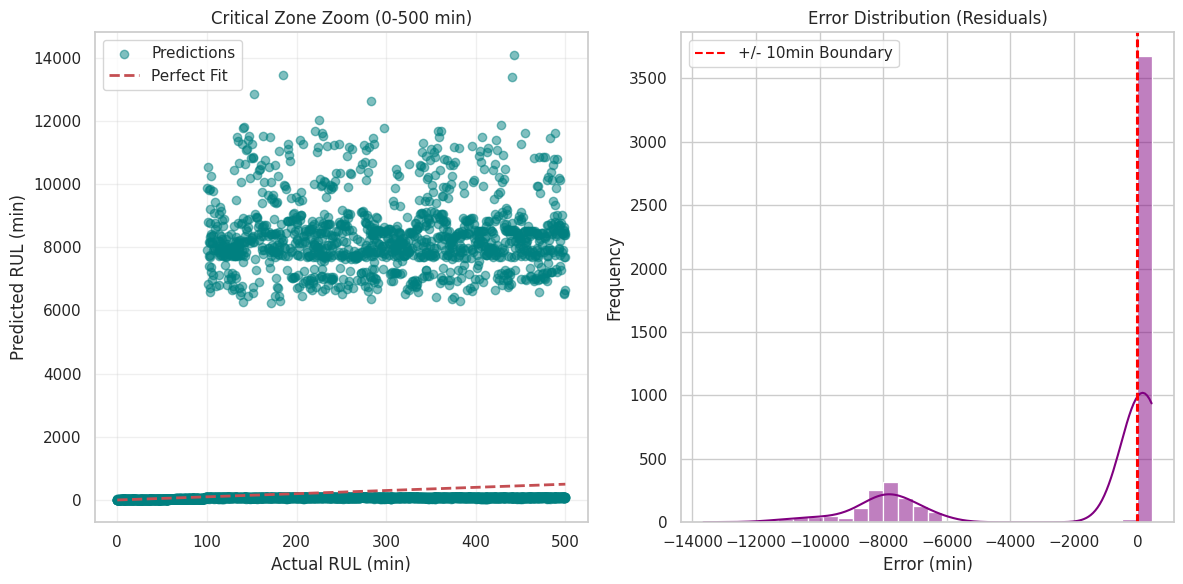

In [66]:
# 10A/ VISUALIZATION - Two-Stage RUL System Predictions vs True RUL
print_header("10A/ VISUALIZATION - Two-Stage RUL System Predictions vs True RUL")

# Visualization: Predicted vs Actual (Zoomed to 0-500 Range)
plt.figure(figsize=(12, 6))

# Filter samples for a clearer view
mask_zoom = y_eval <= 500
y_true_zoom = y_eval[mask_zoom]
y_pred_zoom = final_pred[mask_zoom]

plt.subplot(1, 2, 1)
plt.scatter(y_true_zoom, y_pred_zoom, alpha=0.5, color='teal', label='Predictions')
plt.plot([0, 500], [0, 500], 'r--', lw=2, label='Perfect Fit')
plt.title("Critical Zone Zoom (0-500 min)")
plt.xlabel("Actual RUL (min)")
plt.ylabel("Predicted RUL (min)")
plt.legend()
plt.grid(True, alpha=0.3)

# Visualization: Error Distribution (The Residuals)
plt.subplot(1, 2, 2)
residuals = y_true_zoom - y_pred_zoom
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.axvline(x=10, color='red', linestyle='--', label='+/- 10min Boundary')
plt.axvline(x=-10, color='red', linestyle='--')
plt.title("Error Distribution (Residuals)")
plt.xlabel("Error (min)")
plt.ylabel("Frequency")
plt.legend()

plt.tight_layout()
plt.show()

## 11) Save as ONNX

In [67]:
# 11 / Save models as ONNX

print_header("11/ SAVE MODELS AS ONNX FORMAT")

# BASE MODEL

# Fix feature names inside booster for ONNX compatibility
booster = base_model.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(booster.feature_names))]

n_features = X_train_long.shape[1]

# ONNX input type
initial_type = [('input', FloatTensorType([None, n_features]))]

# XGBoost -> ONNX
onnx_model = onnxmltools.convert_xgboost(
                                            model=base_model,
                                            initial_types=initial_type
                                        )

# Save ONNX file
onnx_path = f"{save_path}process_pump_base_model.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nBASE MODEL is converted to ONNX and saved to: {onnx_path}")

# STG1 CLASSIFIER

# Fix feature names inside booster for ONNX compatibility
booster = stage1_classifier.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(booster.feature_names))]

n_features = X_train_short.shape[1]

# ONNX input type
initial_type = [('input', FloatTensorType([None, n_features]))]

# XGBoost -> ONNX
onnx_model = onnxmltools.convert_xgboost(
                                            model=stage1_classifier,
                                            initial_types=initial_type
                                        )

# Save ONNX file
onnx_path = f"{save_path}process_pump_stage1_classifier.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nSTG1 CLASSIFIER is converted to ONNX and saved to: {onnx_path}")


# STG2A REGRESSOR 

# Fix feature names inside booster for ONNX compatibility
booster = stage2a_regressor.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(booster.feature_names))]

n_features = X_train_c.shape[1]

# ONNX input type
initial_type = [('input', FloatTensorType([None, n_features]))]

# XGBoost -> ONNX
onnx_model = onnxmltools.convert_xgboost(
                                            model=stage2a_regressor,
                                            initial_types=initial_type
                                        )

# Save ONNX file
onnx_path = f"{save_path}process_pump_stage2a_regressor.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nSTG2A REGRESSOR is converted to ONNX and saved to: {onnx_path}")

# STGB REGRESSOR

# Fix feature names inside booster for ONNX compatibility
booster = stage2b_regressor.get_booster()
booster.feature_names = [f"f{i}" for i in range(len(booster.feature_names))]

n_features = X_train_u.shape[1]

# ONNX input type
initial_type = [('input', FloatTensorType([None, n_features]))]

# XGBoost -> ONNX
onnx_model = onnxmltools.convert_xgboost(
                                            model=stage2b_regressor,
                                            initial_types=initial_type
                                        )

# Save ONNX file
onnx_path = f"{save_path}process_pump_stage2b_regressor.onnx"
with open(onnx_path, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"\nSTG2B REGRESSOR is converted to ONNX and saved to: {onnx_path}")

print_footer("ALL MODELS SAVED AS ONNX")



11/ SAVE MODELS AS ONNX FORMAT

BASE MODEL is converted to ONNX and saved to: models_and_features/process_pump/process_pump_base_model.onnx

STG1 CLASSIFIER is converted to ONNX and saved to: models_and_features/process_pump/process_pump_stage1_classifier.onnx

STG2A REGRESSOR is converted to ONNX and saved to: models_and_features/process_pump/process_pump_stage2a_regressor.onnx

STG2B REGRESSOR is converted to ONNX and saved to: models_and_features/process_pump/process_pump_stage2b_regressor.onnx

----------------------------------------------------------------------
ALL MODELS SAVED AS ONNX
----------------------------------------------------------------------
